## Cell 1: Load dataset and perform initial structure audit

In [ ]:


import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load data
df = pd.read_csv(DATA_PATH)

# Basic audit
print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution (Churn):")
print(df["Churn"].value_counts(dropna=False))
print("\nTarget distribution normalized:")
print(df["Churn"].value_counts(normalize=True, dropna=False))

Dataset loaded successfully.
Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

First 5

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

Target distribution (Churn):
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Target distribution normalized:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


# Cell 2: Deeper audit for hidden blanks, unique values, and target consistency

In [ ]:


# Check for blank/whitespace-only entries
blank_counts = (df.astype(str).apply(lambda col: col.str.strip().eq("").sum()))

print("Blank / whitespace-only values per column:")
print(blank_counts[blank_counts > 0].sort_values(ascending=False))

print("\nUnique value counts per column:")
print(df.nunique().sort_values())

print("\nUnique values in target column:")
print(df["Churn"].unique())

print("\nUnique values in SeniorCitizen:")
print(df["SeniorCitizen"].unique())

print("\nSample unique values for selected categorical columns:")
cols_to_check = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

for col in cols_to_check:
    print(f"\n{col}:")
    print(sorted(df[col].astype(str).unique().tolist()))

Blank / whitespace-only values per column:
TotalCharges    11
dtype: int64

Unique value counts per column:
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

Unique values in target column:
['No' 'Yes']

Unique values in SeniorCitizen:
[0 1]

Sample unique values for selected categorical columns:

gender:
['Female', 'Male']

Partner:
['No', 'Yes']

Dependents:
['No', 'Yes']

PhoneService:
['No', 'Yes']

MultipleLines:
['No', 'No phone service', 'Yes']

InternetService:
['DSL', 'Fiber optic', 'No']

OnlineS

# Cell 3: Clean TotalCharges and build column groups

In [ ]:


df_clean = df.copy()

# Convert blank strings in TotalCharges to NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].astype(str).str.strip()
df_clean["TotalCharges"] = df_clean["TotalCharges"].replace("", np.nan)

# Convert to numeric
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# Define target and ID
TARGET_COL = "Churn"
ID_COL = "customerID"

# Binary-like categorical columns
binary_cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService",
    "PaperlessBilling"
]

# Multi-category categorical columns
multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

# Numeric columns
numeric_cols = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"
]

print("Dtypes after cleaning TotalCharges:")
print(df_clean.dtypes)

print("\nMissing values after cleaning:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

print("\nSummary statistics for numeric columns:")
display(df_clean[numeric_cols].describe().T)

print("\nColumn groups:")
print("ID column:", ID_COL)
print("Target column:", TARGET_COL)
print("Binary categorical columns:", binary_cat_cols)
print("Multi-category categorical columns:", multi_cat_cols)
print("Numeric columns:", numeric_cols)

Dtypes after cleaning TotalCharges:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values after cleaning:
TotalCharges    11
dtype: int64

Summary statistics for numeric columns:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.000,0.0000,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80



Column groups:
ID column: customerID
Target column: Churn
Binary categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category categorical columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


# Cell 4: Inspect rows where TotalCharges is missing

In [ ]:


missing_total_df = df_clean[df_clean["TotalCharges"].isna()].copy()

print("Rows with missing TotalCharges:", missing_total_df.shape[0])

display(
    missing_total_df[
        [
            "customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract",
            "PaymentMethod", "InternetService", "Churn"
        ]
    ].sort_values(by=["tenure", "MonthlyCharges"])
)

print("\nTenure distribution among missing TotalCharges rows:")
print(missing_total_df["tenure"].value_counts(dropna=False).sort_index())

print("\nChurn distribution among missing TotalCharges rows:")
print(missing_total_df["Churn"].value_counts(dropna=False))

print("\nSummary of missing TotalCharges rows:")
display(missing_total_df[["tenure", "MonthlyCharges"]].describe().T)

Rows with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,InternetService,Churn
5218,2923-ARZLG,0,19.70,NaN,One year,Mailed check,No,No
3331,7644-OMVMY,0,19.85,NaN,Two year,Mailed check,No,No
4380,2520-SGTTA,0,20.00,NaN,Two year,Mailed check,No,No
753,3115-CZMZD,0,20.25,NaN,Two year,Mailed check,No,No
3826,3213-VVOLG,0,25.35,NaN,Two year,Mailed check,No,No
1082,4367-NUYAO,0,25.75,NaN,Two year,Mailed check,No,No
488,4472-LVYGI,0,52.55,NaN,Two year,Bank transfer (automatic),DSL,No
1340,1371-DWPAZ,0,56.05,NaN,Two year,Credit card (automatic),DSL,No
6754,2775-SEFEE,0,61.90,NaN,Two year,Bank transfer (automatic),DSL,No
6670,4075-WKNIU,0,73.35,NaN,Two year,Mailed check,DSL,No



Tenure distribution among missing TotalCharges rows:
tenure
0    11
Name: count, dtype: int64

Churn distribution among missing TotalCharges rows:
Churn
No    11
Name: count, dtype: int64

Summary of missing TotalCharges rows:


,count,mean,std,min,25%,50%,75%,max
tenure,11.0,0.000000,0.000000,0.0,0.000,0.00,0.000,0.00
MonthlyCharges,11.0,41.418182,23.831484,19.7,20.125,25.75,58.975,80.85


# Cell 5: Target-aware exploratory analysis

In [ ]:


eda_df = df_clean.copy()

# Helper function for churn rate tables
def churn_rate_table(data, col, target="Churn"):
    temp = (
        data.groupby(col)[target]
        .value_counts(normalize=True)
        .rename("proportion")
        .reset_index()
    )
    temp = temp[temp[target] == "Yes"].copy()
    temp = temp.rename(columns={"proportion": "churn_rate"})
    temp["count"] = data[col].value_counts().reindex(temp[col]).values
    return temp.sort_values(by="churn_rate", ascending=False)

key_cats = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity",
    "PaperlessBilling",
    "Partner",
    "Dependents"
]

for col in key_cats:
    print(f"\n===== {col} =====")
    display(churn_rate_table(eda_df, col))

print("\n===== Numeric summary by Churn =====")
display(
    eda_df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]]
    .agg(["mean", "median", "std", "min", "max"])
)


===== Contract =====


,Contract,Churn,churn_rate,count
1,Month-to-month,Yes,0.427097,3875
3,One year,Yes,0.112695,1473
5,Two year,Yes,0.028319,1695



===== InternetService =====


,InternetService,Churn,churn_rate,count
3,Fiber optic,Yes,0.418928,3096
1,DSL,Yes,0.189591,2421
5,No,Yes,0.074050,1526



===== PaymentMethod =====


...

,Partner,Churn,churn_rate,count
1,No,Yes,0.329580,3641
3,Yes,Yes,0.196649,3402



===== Dependents =====


,Dependents,Churn,churn_rate,count
1,No,Yes,0.312791,4933
3,Yes,Yes,0.154502,2110



===== Numeric summary by Churn =====


tenure                           MonthlyCharges                     \
            mean median        std min max           mean  median        std   
Churn                                                                          
No     37.569965   38.0  24.113777   0  72      61.265124  64.425  31.092648   
Yes    17.979133   10.0  19.531123   1  72      74.441332  79.650  24.666053   

                     TotalCharges                                        
         min     max         mean   median          std    min      max  
Churn                                                                    
No     18.25  118.75  2555.344141  1683.60  2329.456984  18.80  8672.45  
Yes    18.85  118.35  1531.796094   703.55  1890.822994  18.85  8684.80

# Cell 6: Create final holdout split and define feature/target sets


In [ ]:


from sklearn.model_selection import train_test_split

work_df = df_clean.copy()

# Binary target encoding
work_df["Churn_Binary"] = work_df["Churn"].map({"No": 0, "Yes": 1})

# Features and target
X = work_df.drop(columns=["Churn", "Churn_Binary"])
y = work_df["Churn_Binary"]

# Final holdout split: 80% development, 20% test
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Recreate column groups from feature matrix
id_col = "customerID"

binary_cat_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"
]

multi_cat_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

categorical_cols = binary_cat_cols + multi_cat_cols
numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

print("Development set shape:", X_dev.shape)
print("Test set shape:", X_test.shape)

print("\nDevelopment target distribution:")
print(y_dev.value_counts())
print(y_dev.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

print("\nFeature columns in X_dev:")
print(X_dev.columns.tolist())

print("\nAny missing values in X_dev?")
print(X_dev.isna().sum()[X_dev.isna().sum() > 0])

print("\nAny missing values in X_test?")
print(X_test.isna().sum()[X_test.isna().sum() > 0])

Development set shape: (5634, 20)
Test set shape: (1409, 20)

Development target distribution:
Churn_Binary
0    4139
1    1495
Name: count, dtype: int64
Churn_Binary
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution:
Churn_Binary
0    1035
1     374
Name: count, dtype: int64
Churn_Binary
0    0.734564
1    0.265436
Name: proportion, dtype: float64

Feature columns in X_dev:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Any missing values in X_dev?
TotalCharges    8
dtype: int64

Any missing values in X_test?
TotalCharges    3
dtype: int64


# Cell 7: Fixed domain-driven feature engineering

In [ ]:


def add_engineered_features(df):
    df = df.copy()

    # Safe numeric helper
    tenure_safe = df["tenure"].replace(0, 1)

    # 1) Monetary and tenure features
    df["avg_charge_per_month"] = df["TotalCharges"] / tenure_safe
    df["charge_tenure_ratio"] = df["MonthlyCharges"] / tenure_safe
    df["high_monthly_charge_flag"] = (df["MonthlyCharges"] > 80).astype(int)
    df["low_tenure_flag"] = (df["tenure"] <= 12).astype(int)
    df["long_tenure_flag"] = (df["tenure"] >= 60).astype(int)

    # 2) Service bundle features
    service_cols = [
        "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
        "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
    ]

    yes_like = {
        "PhoneService": ["Yes"],
        "MultipleLines": ["Yes"],
        "OnlineSecurity": ["Yes"],
        "OnlineBackup": ["Yes"],
        "DeviceProtection": ["Yes"],
        "TechSupport": ["Yes"],
        "StreamingTV": ["Yes"],
        "StreamingMovies": ["Yes"]
    }

    df["service_count"] = 0
    for col in service_cols:
        df["service_count"] += df[col].isin(yes_like[col]).astype(int)

    support_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    df["support_service_count"] = sum(df[col].eq("Yes").astype(int) for col in support_cols)

    streaming_cols = ["StreamingTV", "StreamingMovies"]
    df["streaming_service_count"] = sum(df[col].eq("Yes").astype(int) for col in streaming_cols)

    df["internet_dependent_flag"] = df["InternetService"].isin(["DSL", "Fiber optic"]).astype(int)
    df["no_support_bundle_flag"] = (df["support_service_count"] == 0).astype(int)

    # 3) Contract and payment risk features
    contract_risk_map = {
        "Month-to-month": 2,
        "One year": 1,
        "Two year": 0
    }
    payment_risk_map = {
        "Electronic check": 3,
        "Mailed check": 2,
        "Bank transfer (automatic)": 1,
        "Credit card (automatic)": 1
    }

    df["contract_risk_score"] = df["Contract"].map(contract_risk_map)
    df["payment_friction_score"] = df["PaymentMethod"].map(payment_risk_map)

    df["paperless_auto_payment_mismatch"] = (
        (df["PaperlessBilling"] == "Yes") &
        (~df["PaymentMethod"].isin(["Bank transfer (automatic)", "Credit card (automatic)"]))
    ).astype(int)

    df["month_to_month_high_risk_flag"] = (
        (df["Contract"] == "Month-to-month") &
        (df["MonthlyCharges"] > 70)
    ).astype(int)

    # 4) Interaction features
    df["tenure_x_monthlycharges"] = df["tenure"] * df["MonthlyCharges"]

    df["internetservice_x_techsupport"] = (
        df["InternetService"].astype(str) + "_" + df["TechSupport"].astype(str)
    )

    df["seniorcitizen_x_dependents"] = (
        df["SeniorCitizen"].astype(str) + "_" + df["Dependents"].astype(str)
    )

    df["contract_x_paymentmethod"] = (
        df["Contract"].astype(str) + "_" + df["PaymentMethod"].astype(str)
    )

    df["support_bundle_x_monthlycharges"] = df["support_service_count"] * df["MonthlyCharges"]

    # 5) Segment features (rule-based bins for now)
    df["tenure_bin"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12", "13-24", "25-48", "49-72"]
    ).astype(str)

    df["monthly_charge_bin"] = pd.cut(
        df["MonthlyCharges"],
        bins=[-np.inf, 35, 70, 90, np.inf],
        labels=["low", "medium", "high", "very_high"]
    ).astype(str)

    df["total_charge_bin"] = pd.cut(
        df["TotalCharges"],
        bins=[-np.inf, 500, 2000, 5000, np.inf],
        labels=["low", "medium", "high", "very_high"]
    ).astype(str)

    return df


# Apply feature engineering
X_dev_fe = add_engineered_features(X_dev)
X_test_fe = add_engineered_features(X_test)

print("Original X_dev shape:", X_dev.shape)
print("Engineered X_dev shape:", X_dev_fe.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Engineered X_test shape:", X_test_fe.shape)

new_cols = [col for col in X_dev_fe.columns if col not in X_dev.columns]
print("\nNew engineered columns:")
print(new_cols)

print("\nMissing values in engineered development set:")
print(X_dev_fe.isna().sum()[X_dev_fe.isna().sum() > 0].sort_values(ascending=False))

print("\nPreview of engineered columns:")
preview_cols = [
    "tenure", "MonthlyCharges", "TotalCharges",
    "avg_charge_per_month", "charge_tenure_ratio",
    "service_count", "support_service_count", "streaming_service_count",
    "contract_risk_score", "payment_friction_score",
    "month_to_month_high_risk_flag", "tenure_bin",
    "monthly_charge_bin", "total_charge_bin"
]
display(X_dev_fe[preview_cols].head())

Original X_dev shape: (5634, 20)
Engineered X_dev shape: (5634, 42)

Original X_test shape: (1409, 20)
Engineered X_test shape: (1409, 42)

New engineered columns:
['avg_charge_per_month', 'charge_tenure_ratio', 'high_monthly_charge_flag', 'low_tenure_flag', 'long_tenure_flag', 'service_count', 'support_service_count', 'streaming_service_count', 'internet_dependent_flag', 'no_support_bundle_flag', 'contract_risk_score', 'payment_friction_score', 'paperless_auto_payment_mismatch', 'month_to_month_high_risk_flag', 'tenure_x_monthlycharges', 'internetservice_x_techsupport', 'seniorcitizen_x_dependents', 'contract_x_paymentmethod', 'support_bundle_x_monthlycharges', 'tenure_bin', 'monthly_charge_bin', 'total_charge_bin']

Missing values in engineered development set:
TotalCharges            8
avg_charge_per_month    8
dtype: int64

Preview of engineered columns:


,tenure,MonthlyCharges,TotalCharges,avg_charge_per_month,charge_tenure_ratio,service_count,support_service_count,streaming_service_count,contract_risk_score,payment_friction_score,month_to_month_high_risk_flag,tenure_bin,monthly_charge_bin,total_charge_bin
3738,35,49.20,1701.65,48.618571,1.405714,3,1,2,2,3,0,25-48,medium,medium
3151,15,75.10,1151.55,76.770000,5.006667,2,1,0,2,2,1,13-24,high,medium
4860,13,40.55,590.35,45.411538,3.119231,3,3,0,0,2,0,13-24,medium,medium
3867,26,73.50,1905.70,73.296154,2.826923,5,2,2,0,1,0,25-48,high,medium
3810,1,44.55,44.55,44.550000,44.550000,1,0,0,2,3,0,0-12,medium,low


# Cell 8: Add KMeans customer segment feature using development data only

In [ ]:


from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Numeric columns used for clustering
cluster_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_charge_per_month",
    "charge_tenure_ratio",
    "service_count",
    "support_service_count",
    "streaming_service_count",
    "contract_risk_score",
    "payment_friction_score",
    "tenure_x_monthlycharges",
    "support_bundle_x_monthlycharges"
]

# Prepare development data for fitting KMeans
cluster_imputer = SimpleImputer(strategy="median")
cluster_scaler = StandardScaler()

X_dev_cluster_num = cluster_imputer.fit_transform(X_dev_fe[cluster_features])
X_dev_cluster_scaled = cluster_scaler.fit_transform(X_dev_cluster_num)

X_test_cluster_num = cluster_imputer.transform(X_test_fe[cluster_features])
X_test_cluster_scaled = cluster_scaler.transform(X_test_cluster_num)

# Fixed number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

X_dev_fe["customer_segment_kmeans"] = kmeans.fit_predict(X_dev_cluster_scaled)
X_test_fe["customer_segment_kmeans"] = kmeans.predict(X_test_cluster_scaled)

print("Segment counts in development set:")
print(X_dev_fe["customer_segment_kmeans"].value_counts().sort_index())

print("\nSegment counts in test set:")
print(X_test_fe["customer_segment_kmeans"].value_counts().sort_index())

print("\nChurn rate by segment in development set:")
segment_churn = pd.DataFrame({
    "segment": X_dev_fe["customer_segment_kmeans"],
    "churn": y_dev.values
}).groupby("segment")["churn"].agg(["count", "mean"]).rename(columns={"mean": "churn_rate"})
display(segment_churn.sort_values("churn_rate", ascending=False))

print("\nUpdated development shape:", X_dev_fe.shape)
print("Updated test shape:", X_test_fe.shape)

Segment counts in development set:
customer_segment_kmeans
0     558
1    1755
2    1845
3    1476
Name: count, dtype: int64

Segment counts in test set:
customer_segment_kmeans
0    153
1    452
2    463
3    341
Name: count, dtype: int64

Churn rate by segment in development set:


,count,churn_rate
segment,,
0,558,0.666667
2,1845,0.386450
1,1755,0.129345
3,1476,0.123984



Updated development shape: (5634, 43)
Updated test shape: (1409, 43)


# Cell 9: Finalize modeling column groups after feature engineering

In [ ]:


# Original columns
original_categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

original_numeric_cols = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"
]

# New engineered numeric columns
engineered_numeric_cols = [
    "avg_charge_per_month",
    "charge_tenure_ratio",
    "high_monthly_charge_flag",
    "low_tenure_flag",
    "long_tenure_flag",
    "service_count",
    "support_service_count",
    "streaming_service_count",
    "internet_dependent_flag",
    "no_support_bundle_flag",
    "contract_risk_score",
    "payment_friction_score",
    "paperless_auto_payment_mismatch",
    "month_to_month_high_risk_flag",
    "tenure_x_monthlycharges",
    "support_bundle_x_monthlycharges",
    "customer_segment_kmeans"
]

# New engineered categorical columns
engineered_categorical_cols = [
    "internetservice_x_techsupport",
    "seniorcitizen_x_dependents",
    "contract_x_paymentmethod",
    "tenure_bin",
    "monthly_charge_bin",
    "total_charge_bin"
]

# Final fixed column groups
final_categorical_cols = original_categorical_cols + engineered_categorical_cols
final_numeric_cols = original_numeric_cols + engineered_numeric_cols

# Final modeling dataset drops ID only
X_dev_model = X_dev_fe.drop(columns=["customerID"]).copy()
X_test_model = X_test_fe.drop(columns=["customerID"]).copy()

print("X_dev_model shape:", X_dev_model.shape)
print("X_test_model shape:", X_test_model.shape)

print("\nFinal categorical column count:", len(final_categorical_cols))
print("Final numeric column count:", len(final_numeric_cols))

print("\nTotal expected modeled columns:", len(final_categorical_cols) + len(final_numeric_cols))
print("Actual modeled columns:", X_dev_model.shape[1])

print("\nMissing values in development modeling set:")
print(X_dev_model.isna().sum()[X_dev_model.isna().sum() > 0].sort_values(ascending=False))

print("\nMissing values in test modeling set:")
print(X_test_model.isna().sum()[X_test_model.isna().sum() > 0].sort_values(ascending=False))

print("\nCategorical columns:")
print(final_categorical_cols)

print("\nNumeric columns:")
print(final_numeric_cols)

X_dev_model shape: (5634, 42)
X_test_model shape: (1409, 42)

Final categorical column count: 21
Final numeric column count: 21

Total expected modeled columns: 42
Actual modeled columns: 42

Missing values in development modeling set:
TotalCharges            8
avg_charge_per_month    8
dtype: int64

Missing values in test modeling set:
TotalCharges            3
avg_charge_per_month    3
dtype: int64

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'internetservice_x_techsupport', 'seniorcitizen_x_dependents', 'contract_x_paymentmethod', 'tenure_bin', 'monthly_charge_bin', 'total_charge_bin']

Numeric columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_charge_per_month', 'charge_tenure_ratio', 'high_monthly_charge_flag', 'low_tenure_flag', 'long_tenure_

# Cell 10: Logistic Regression baseline with fold-safe preprocessing

In [ ]:


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

# Preprocessing
numeric_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_lr = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lr, final_numeric_cols),
        ("cat", categorical_transformer_lr, final_categorical_cols)
    ]
)

# Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lr),
    ("classifier", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

# Fit
lr_pipeline.fit(X_dev_model, y_dev)

# Predict
y_test_pred_lr = lr_pipeline.predict(X_test_model)
y_test_prob_lr = lr_pipeline.predict_proba(X_test_model)[:, 1]

# Metrics
lr_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_lr),
    "Precision": precision_score(y_test, y_test_pred_lr),
    "Recall": recall_score(y_test, y_test_pred_lr),
    "F1": f1_score(y_test, y_test_pred_lr),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_lr),
    "PR_AUC": average_precision_score(y_test, y_test_prob_lr)
}

print("Logistic Regression Test Metrics:")
for k, v in lr_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lr, digits=4))

Logistic Regression Test Metrics:
Accuracy: 0.7452
Precision: 0.5130
Recall: 0.7914
F1: 0.6225
ROC_AUC: 0.8463
PR_AUC: 0.6627

Confusion Matrix:
[[754 281]
 [ 78 296]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9062    0.7285    0.8077      1035
           1     0.5130    0.7914    0.6225       374

    accuracy                         0.7452      1409
   macro avg     0.7096    0.7600    0.7151      1409
weighted avg     0.8019    0.7452    0.7586      1409



# Cell 11: Random Forest baseline with fold-safe preprocessing

In [ ]:


from sklearn.ensemble import RandomForestClassifier

# Preprocessing for Random Forest
numeric_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_rf = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_rf = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_rf, final_numeric_cols),
        ("cat", categorical_transformer_rf, final_categorical_cols)
    ]
)

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_rf),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# Fit
rf_pipeline.fit(X_dev_model, y_dev)

# Predict
y_test_pred_rf = rf_pipeline.predict(X_test_model)
y_test_prob_rf = rf_pipeline.predict_proba(X_test_model)[:, 1]

# Metrics
rf_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_rf),
    "Precision": precision_score(y_test, y_test_pred_rf),
    "Recall": recall_score(y_test, y_test_pred_rf),
    "F1": f1_score(y_test, y_test_pred_rf),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_rf),
    "PR_AUC": average_precision_score(y_test, y_test_prob_rf)
}

print("Random Forest Test Metrics:")
for k, v in rf_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_rf, digits=4))

Random Forest Test Metrics:
Accuracy: 0.7736
Precision: 0.5696
Recall: 0.6016
F1: 0.5852
ROC_AUC: 0.8362
PR_AUC: 0.6420

Confusion Matrix:
[[865 170]
 [149 225]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8531    0.8357    0.8443      1035
           1     0.5696    0.6016    0.5852       374

    accuracy                         0.7736      1409
   macro avg     0.7113    0.7187    0.7147      1409
weighted avg     0.7778    0.7736    0.7755      1409



# Cell 12: XGBoost baseline with fold-safe preprocessing

In [ ]:


from xgboost import XGBClassifier

# Compute scale_pos_weight from development set
neg_count = (y_dev == 0).sum()
pos_count = (y_dev == 1).sum()
scale_pos_weight = neg_count / pos_count

print("scale_pos_weight:", round(scale_pos_weight, 4))

# Preprocessing for XGBoost
numeric_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_xgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_xgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_xgb, final_numeric_cols),
        ("cat", categorical_transformer_xgb, final_categorical_cols)
    ]
)

# XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_xgb),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

# Fit
xgb_pipeline.fit(X_dev_model, y_dev)

# Predict
y_test_pred_xgb = xgb_pipeline.predict(X_test_model)
y_test_prob_xgb = xgb_pipeline.predict_proba(X_test_model)[:, 1]

# Metrics
xgb_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_xgb),
    "Precision": precision_score(y_test, y_test_pred_xgb),
    "Recall": recall_score(y_test, y_test_pred_xgb),
    "F1": f1_score(y_test, y_test_pred_xgb),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_xgb),
    "PR_AUC": average_precision_score(y_test, y_test_prob_xgb)
}

print("\nXGBoost Test Metrics:")
for k, v in xgb_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_xgb, digits=4))

scale_pos_weight: 2.7686

XGBoost Test Metrics:
Accuracy: 0.7566
Precision: 0.5280
Recall: 0.7807
F1: 0.6300
ROC_AUC: 0.8412
PR_AUC: 0.6545

Confusion Matrix:
[[774 261]
 [ 82 292]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9042    0.7478    0.8186      1035
           1     0.5280    0.7807    0.6300       374

    accuracy                         0.7566      1409
   macro avg     0.7161    0.7643    0.7243      1409
weighted avg     0.8044    0.7566    0.7685      1409



# Cell 13: LightGBM baseline with fold-safe preprocessing

In [ ]:


from lightgbm import LGBMClassifier

# Preprocessing for LightGBM
numeric_transformer_lgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer_lgb = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_lgb = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_lgb, final_numeric_cols),
        ("cat", categorical_transformer_lgb, final_categorical_cols)
    ]
)

# LightGBM pipeline
lgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_lgb),
    ("classifier", LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    ))
])

# Fit
lgb_pipeline.fit(X_dev_model, y_dev)

# Predict
y_test_pred_lgb = lgb_pipeline.predict(X_test_model)
y_test_prob_lgb = lgb_pipeline.predict_proba(X_test_model)[:, 1]

# Metrics
lgb_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_lgb),
    "Precision": precision_score(y_test, y_test_pred_lgb),
    "Recall": recall_score(y_test, y_test_pred_lgb),
    "F1": f1_score(y_test, y_test_pred_lgb),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_lgb),
    "PR_AUC": average_precision_score(y_test, y_test_prob_lgb)
}

print("LightGBM Test Metrics:")
for k, v in lgb_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lgb))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_lgb, digits=4))

LightGBM Test Metrics:
Accuracy: 0.7637
Precision: 0.5408
Recall: 0.7273
F1: 0.6203
ROC_AUC: 0.8344
PR_AUC: 0.6338

Confusion Matrix:
[[804 231]
 [102 272]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8874    0.7768    0.8284      1035
           1     0.5408    0.7273    0.6203       374

    accuracy                         0.7637      1409
   macro avg     0.7141    0.7520    0.7244      1409
weighted avg     0.7954    0.7637    0.7732      1409



# Cell 14: CatBoost baseline with native categorical handling

In [ ]:


from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

# Build CatBoost-specific data copies
X_dev_cat = X_dev_model.copy()
X_test_cat = X_test_model.copy()

# CatBoost handles categorical columns as string/object nicely
# Ensure categorical columns are strings and numeric columns are numeric
for col in final_categorical_cols:
    X_dev_cat[col] = X_dev_cat[col].astype(str)
    X_test_cat[col] = X_test_cat[col].astype(str)

for col in final_numeric_cols:
    X_dev_cat[col] = pd.to_numeric(X_dev_cat[col], errors="coerce")
    X_test_cat[col] = pd.to_numeric(X_test_cat[col], errors="coerce")

# CatBoost needs categorical feature indices
cat_feature_indices = [X_dev_cat.columns.get_loc(col) for col in final_categorical_cols]

# Class weights based on development set
neg_count = (y_dev == 0).sum()
pos_count = (y_dev == 1).sum()
class_weights = [1.0, neg_count / pos_count]

print("CatBoost class_weights:", class_weights)

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=class_weights,
    random_seed=42,
    verbose=False
)

# Fit
cat_model.fit(
    X_dev_cat,
    y_dev,
    cat_features=cat_feature_indices
)

# Predict
y_test_pred_cat = cat_model.predict(X_test_cat)
y_test_pred_cat = np.array(y_test_pred_cat).astype(int).ravel()

y_test_prob_cat = cat_model.predict_proba(X_test_cat)[:, 1]

# Metrics
cat_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_cat),
    "Precision": precision_score(y_test, y_test_pred_cat),
    "Recall": recall_score(y_test, y_test_pred_cat),
    "F1": f1_score(y_test, y_test_pred_cat),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_cat),
    "PR_AUC": average_precision_score(y_test, y_test_prob_cat)
}

print("\nCatBoost Test Metrics:")
for k, v in cat_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_cat))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_cat, digits=4))

CatBoost class_weights: [1.0, np.float64(2.768561872909699)]

CatBoost Test Metrics:
Accuracy: 0.7608
Precision: 0.5337
Recall: 0.7834
F1: 0.6349
ROC_AUC: 0.8455
PR_AUC: 0.6624

Confusion Matrix:
[[779 256]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9058    0.7527    0.8222      1035
           1     0.5337    0.7834    0.6349       374

    accuracy                         0.7608      1409
   macro avg     0.7198    0.7680    0.7285      1409
weighted avg     0.8070    0.7608    0.7725      1409



# Cell 15: Check GPU and package availability for deep-tabular models

In [ ]:


import sys
import importlib.util
import torch

print("Python version:", sys.version)
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA device count:", torch.cuda.device_count())

packages_to_check = [
    "pytorch_tabnet",
    "pytorch_tabular",
    "lightgbm",
    "catboost",
    "xgboost",
    "optuna"
]

print("\nPackage availability:")
for pkg in packages_to_check:
    available = importlib.util.find_spec(pkg) is not None
    print(f"{pkg}: {'FOUND' if available else 'NOT FOUND'}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch version: 2.9.0+cpu
CUDA available: False

Package availability:
pytorch_tabnet: NOT FOUND
pytorch_tabular: NOT FOUND
lightgbm: FOUND
catboost: FOUND
xgboost: FOUND
optuna: FOUND


# Cell 16: Install deep-tabular libraries in the current CPU session

In [ ]:
!pip install -q pytorch-tabnet pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 11.3 MB/s eta 0:00:00


# Cell 17: Verify deep-tabular package imports

In [ ]:


import importlib
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

tabnet_spec = importlib.util.find_spec("pytorch_tabnet")
pytorch_tabular_spec = importlib.util.find_spec("pytorch_tabular")

print("\npytorch_tabnet found:", tabnet_spec is not None)
print("pytorch_tabular found:", pytorch_tabular_spec is not None)

from pytorch_tabnet.tab_model import TabNetClassifier
print("\nTabNetClassifier import: SUCCESS")

from pytorch_tabular import TabularModel
print("TabularModel import: SUCCESS")

PyTorch version: 2.9.0+cpu
CUDA available: False

pytorch_tabnet found: True
pytorch_tabular found: True

TabNetClassifier import: SUCCESS
TabularModel import: SUCCESS


# Quick check: verify pytorch_tabular import separately

In [ ]:


from pytorch_tabular import TabularModel
print("TabularModel import: SUCCESS")

TabularModel import: SUCCESS


# Cell 18: Prepare data for TabNet

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

# Copy development and test sets
X_dev_tabnet = X_dev_model.copy()
X_test_tabnet = X_test_model.copy()

# Split development into train/validation for TabNet only
X_train_tabnet, X_val_tabnet, y_train_tabnet, y_val_tabnet = train_test_split(
    X_dev_tabnet,
    y_dev,
    test_size=0.20,
    stratify=y_dev,
    random_state=42
)

# Imputers
num_imputer_tabnet = SimpleImputer(strategy="median")
cat_imputer_tabnet = SimpleImputer(strategy="most_frequent")

# Impute numeric columns
X_train_tabnet_num = pd.DataFrame(
    num_imputer_tabnet.fit_transform(X_train_tabnet[final_numeric_cols]),
    columns=final_numeric_cols,
    index=X_train_tabnet.index
)
X_val_tabnet_num = pd.DataFrame(
    num_imputer_tabnet.transform(X_val_tabnet[final_numeric_cols]),
    columns=final_numeric_cols,
    index=X_val_tabnet.index
)
X_test_tabnet_num = pd.DataFrame(
    num_imputer_tabnet.transform(X_test_tabnet[final_numeric_cols]),
    columns=final_numeric_cols,
    index=X_test_tabnet.index
)

# Impute categorical columns
X_train_tabnet_cat = pd.DataFrame(
    cat_imputer_tabnet.fit_transform(X_train_tabnet[final_categorical_cols]),
    columns=final_categorical_cols,
    index=X_train_tabnet.index
)
X_val_tabnet_cat = pd.DataFrame(
    cat_imputer_tabnet.transform(X_val_tabnet[final_categorical_cols]),
    columns=final_categorical_cols,
    index=X_val_tabnet.index
)
X_test_tabnet_cat = pd.DataFrame(
    cat_imputer_tabnet.transform(X_test_tabnet[final_categorical_cols]),
    columns=final_categorical_cols,
    index=X_test_tabnet.index
)

# Label encode each categorical column consistently
label_encoders_tabnet = {}
for col in final_categorical_cols:
    le = LabelEncoder()
    train_vals = X_train_tabnet_cat[col].astype(str)
    le.fit(train_vals)

    # handle unseen values in val/test by extending classes if needed
    known_classes = set(le.classes_)

    for df_part in [X_val_tabnet_cat, X_test_tabnet_cat]:
        unseen = set(df_part[col].astype(str).unique()) - known_classes
        if unseen:
            le.classes_ = np.concatenate([le.classes_, np.array(sorted(unseen), dtype=object)])
            known_classes = set(le.classes_)

    X_train_tabnet_cat[col] = le.transform(X_train_tabnet_cat[col].astype(str))
    X_val_tabnet_cat[col] = le.transform(X_val_tabnet_cat[col].astype(str))
    X_test_tabnet_cat[col] = le.transform(X_test_tabnet_cat[col].astype(str))

    label_encoders_tabnet[col] = le

# Combine numeric + categorical
X_train_tabnet_final = pd.concat([X_train_tabnet_num, X_train_tabnet_cat], axis=1)
X_val_tabnet_final = pd.concat([X_val_tabnet_num, X_val_tabnet_cat], axis=1)
X_test_tabnet_final = pd.concat([X_test_tabnet_num, X_test_tabnet_cat], axis=1)

# Ensure column order is identical
X_val_tabnet_final = X_val_tabnet_final[X_train_tabnet_final.columns]
X_test_tabnet_final = X_test_tabnet_final[X_train_tabnet_final.columns]

# TabNet categorical metadata
tabnet_feature_columns = X_train_tabnet_final.columns.tolist()
cat_idxs = [tabnet_feature_columns.index(col) for col in final_categorical_cols]
cat_dims = [int(X_train_tabnet_cat[col].nunique()) for col in final_categorical_cols]

print("Train shape:", X_train_tabnet_final.shape)
print("Validation shape:", X_val_tabnet_final.shape)
print("Test shape:", X_test_tabnet_final.shape)

print("\nAny missing values in TabNet train:", X_train_tabnet_final.isna().sum().sum())
print("Any missing values in TabNet val:", X_val_tabnet_final.isna().sum().sum())
print("Any missing values in TabNet test:", X_test_tabnet_final.isna().sum().sum())

print("\nNumber of categorical feature indices:", len(cat_idxs))
print("Number of categorical dimensions:", len(cat_dims))
print("First 10 cat_idxs:", cat_idxs[:10])
print("First 10 cat_dims:", cat_dims[:10])

display(X_train_tabnet_final.head())

Train shape: (4507, 42)
Validation shape: (1127, 42)
Test shape: (1409, 42)

Any missing values in TabNet train: 0
Any missing values in TabNet val: 0
Any missing values in TabNet test: 0

Number of categorical feature indices: 21
Number of categorical dimensions: 21
First 10 cat_idxs: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
First 10 cat_dims: [2, 2, 2, 2, 2, 3, 3, 3, 3, 3]


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,avg_charge_per_month,charge_tenure_ratio,high_monthly_charge_flag,low_tenure_flag,long_tenure_flag,service_count,...,StreamingTV,StreamingMovies,Contract,PaymentMethod,internetservice_x_techsupport,seniorcitizen_x_dependents,contract_x_paymentmethod,tenure_bin,monthly_charge_bin,total_charge_bin
6592,0.0,26.0,59.45,1507.00,57.961538,2.286538,0.0,0.0,0.0,3.0,...,2,0,1,1,1,0,5,2,2,2
464,1.0,72.0,116.05,8404.90,116.734722,1.611806,1.0,0.0,1.0,8.0,...,2,2,2,0,3,2,8,3,3,4
5420,0.0,70.0,114.30,8244.30,117.775714,1.632857,1.0,0.0,1.0,8.0,...,2,2,2,1,3,0,9,3,3,4
629,1.0,49.0,90.05,4547.25,92.801020,1.837755,1.0,0.0,0.0,4.0,...,0,2,0,1,2,2,1,3,3,0
431,0.0,72.0,65.20,4784.45,66.450694,0.905556,0.0,0.0,1.0,6.0,...,2,2,2,1,1,1,9,3,2,0


# Cell 19: Train and evaluate TabNet on CPU-friendly settings

In [ ]:


from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

# Convert to numpy
X_train_tabnet_np = X_train_tabnet_final.values.astype(np.float32)
X_val_tabnet_np = X_val_tabnet_final.values.astype(np.float32)
X_test_tabnet_np = X_test_tabnet_final.values.astype(np.float32)

y_train_tabnet_np = y_train_tabnet.values.astype(int)
y_val_tabnet_np = y_val_tabnet.values.astype(int)
y_test_np = y_test.values.astype(int)

# Class imbalance ratio
neg_count_tabnet = (y_train_tabnet_np == 0).sum()
pos_count_tabnet = (y_train_tabnet_np == 1).sum()
pos_weight_tabnet = neg_count_tabnet / pos_count_tabnet

print("TabNet pos_weight:", round(pos_weight_tabnet, 4))

tabnet_model = TabNetClassifier(
    cat_idxs=cat_idxs,
    cat_dims=cat_dims,
    cat_emb_dim=3,
    n_d=16,
    n_a=16,
    n_steps=4,
    gamma=1.3,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    mask_type="entmax",
    scheduler_params={"step_size": 15, "gamma": 0.8},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    seed=42,
    verbose=1
)

tabnet_model.fit(
    X_train=X_train_tabnet_np,
    y_train=y_train_tabnet_np,
    eval_set=[(X_val_tabnet_np, y_val_tabnet_np)],
    eval_name=["val"],
    eval_metric=["auc"],
    max_epochs=40,
    patience=10,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False,
    weights={0: 1.0, 1: float(pos_weight_tabnet)}
)

# Predict
y_test_prob_tabnet = tabnet_model.predict_proba(X_test_tabnet_np)[:, 1]
y_test_pred_tabnet = (y_test_prob_tabnet >= 0.5).astype(int)

# Metrics
tabnet_results = {
    "Accuracy": accuracy_score(y_test_np, y_test_pred_tabnet),
    "Precision": precision_score(y_test_np, y_test_pred_tabnet),
    "Recall": recall_score(y_test_np, y_test_pred_tabnet),
    "F1": f1_score(y_test_np, y_test_pred_tabnet),
    "ROC_AUC": roc_auc_score(y_test_np, y_test_prob_tabnet),
    "PR_AUC": average_precision_score(y_test_np, y_test_prob_tabnet)
}

print("\nTabNet Test Metrics:")
for k, v in tabnet_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_np, y_test_pred_tabnet))

print("\nClassification Report:")
print(classification_report(y_test_np, y_test_pred_tabnet, digits=4))

TabNet pos_weight: 2.7684
epoch 0  | loss: 1.04226 | val_auc: 0.63129 |  0:00:00s
epoch 1  | loss: 0.56987 | val_auc: 0.7279  |  0:00:01s
epoch 2  | loss: 0.52909 | val_auc: 0.7562  |  0:00:01s
epoch 3  | loss: 0.5151  | val_auc: 0.7821  |  0:00:02s
epoch 4  | loss: 0.50216 | val_auc: 0.81823 |  0:00:02s
epoch 5  | loss: 0.48714 | val_auc: 0.80531 |  0:00:03s
epoch 6  | loss: 0.49231 | val_auc: 0.81418 |  0:00:03s
epoch 7  | loss: 0.4728  | val_auc: 0.81323 |  0:00:04s
epoch 8  | loss: 0.46692 | val_auc: 0.81657 |  0:00:04s
epoch 9  | loss: 0.45621 | val_auc: 0.81343 |  0:00:05s
epoch 10 | loss: 0.46913 | val_auc: 0.81458 |  0:00:05s
epoch 11 | loss: 0.47599 | val_auc: 0.82724 |  0:00:06s
epoch 12 | loss: 0.47687 | val_auc: 0.82883 |  0:00:06s
epoch 13 | loss: 0.4602  | val_auc: 0.82937 |  0:00:07s
epoch 14 | loss: 0.45309 | val_auc: 0.82763 |  0:00:07s
epoch 15 | loss: 0.45665 | val_auc: 0.83296 |  0:00:08s
epoch 16 | loss: 0.45174 | val_auc: 0.83427 |  0:00:09s
epoch 17 | loss: 0.454

# Cell 20: Prepare FT-Transformer train/validation/test dataframes

##  Build dataframes for pytorch-tabular FT-Transformer

In [ ]:



train_ft = X_train_tabnet.copy()
val_ft = X_val_tabnet.copy()
test_ft = X_test_tabnet.copy()

train_ft["Churn_Binary"] = y_train_tabnet.values
val_ft["Churn_Binary"] = y_val_tabnet.values
test_ft["Churn_Binary"] = y_test.values

print("FT-Transformer train shape:", train_ft.shape)
print("FT-Transformer validation shape:", val_ft.shape)
print("FT-Transformer test shape:", test_ft.shape)

print("\nTarget distribution in train:")
print(train_ft["Churn_Binary"].value_counts(normalize=True))

print("\nTarget distribution in validation:")
print(val_ft["Churn_Binary"].value_counts(normalize=True))

print("\nTarget distribution in test:")
print(test_ft["Churn_Binary"].value_counts(normalize=True))

print("\nMissing values in FT train:")
print(train_ft.isna().sum()[train_ft.isna().sum() > 0])

print("\nSample rows:")
display(train_ft.head())

FT-Transformer train shape: (4507, 43)
FT-Transformer validation shape: (1127, 43)
FT-Transformer test shape: (1409, 43)

Target distribution in train:
Churn_Binary
0    0.734635
1    0.265365
Name: proportion, dtype: float64

Target distribution in validation:
Churn_Binary
0    0.734694
1    0.265306
Name: proportion, dtype: float64

Target distribution in test:
Churn_Binary
0    0.734564
1    0.265436
Name: proportion, dtype: float64

Missing values in FT train:
TotalCharges            7
avg_charge_per_month    7
dtype: int64

Sample rows:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,tenure_x_monthlycharges,internetservice_x_techsupport,seniorcitizen_x_dependents,contract_x_paymentmethod,support_bundle_x_monthlycharges,tenure_bin,monthly_charge_bin,total_charge_bin,customer_segment_kmeans,Churn_Binary
6592,Male,0,No,No,26,Yes,No,DSL,No,No,...,1545.70,DSL_Yes,0_No,One year_Credit card (automatic),59.45,25-48,medium,medium,2,0
464,Male,1,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,...,8355.60,Fiber optic_Yes,1_No,Two year_Bank transfer (automatic),464.20,49-72,very_high,very_high,3,0
5420,Male,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,Yes,...,8001.00,Fiber optic_Yes,0_No,Two year_Credit card (automatic),457.20,49-72,very_high,very_high,3,0
629,Male,1,Yes,No,49,Yes,Yes,Fiber optic,No,Yes,...,4412.45,Fiber optic_No,1_No,Month-to-month_Credit card (automatic),90.05,49-72,very_high,high,2,1
431,Female,0,Yes,Yes,72,No,No phone service,DSL,Yes,Yes,...,4694.40,DSL_Yes,0_Yes,Two year_Credit card (automatic),260.80,49-72,medium,high,3,0


# Cell 21: Train and evaluate FT-Transformer (updated, version-robust)

In [ ]:


from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import inspect

# -----------------------------
# 1) Impute missing numeric values
# -----------------------------
ft_numeric_imputer = SimpleImputer(strategy="median")

train_ft_imputed = train_ft.copy()
val_ft_imputed = val_ft.copy()
test_ft_imputed = test_ft.copy()

train_ft_imputed[final_numeric_cols] = ft_numeric_imputer.fit_transform(train_ft[final_numeric_cols])
val_ft_imputed[final_numeric_cols] = ft_numeric_imputer.transform(val_ft[final_numeric_cols])
test_ft_imputed[final_numeric_cols] = ft_numeric_imputer.transform(test_ft[final_numeric_cols])

print("Missing values after imputation (train):", train_ft_imputed.isna().sum().sum())
print("Missing values after imputation (val):", val_ft_imputed.isna().sum().sum())
print("Missing values after imputation (test):", test_ft_imputed.isna().sum().sum())

# -----------------------------
# 2) Build configs
# -----------------------------
data_config = DataConfig(
    target=["Churn_Binary"],
    continuous_cols=final_numeric_cols,
    categorical_cols=final_categorical_cols,
)

# Make FTTransformerConfig creation robust to installed version
ft_sig = inspect.signature(FTTransformerConfig.__init__)
ft_supported = set(ft_sig.parameters.keys())

ft_kwargs = {
    "task": "classification",
    "learning_rate": 1e-3,
    "input_embed_dim": 24,
    "num_heads": 4,
    "num_attn_blocks": 4,
    "transformer_activation": "GEGLU",
    "batch_norm_continuous_input": True,
}

# Keep only args supported by the installed version
ft_kwargs = {k: v for k, v in ft_kwargs.items() if k in ft_supported}

print("\nFTTransformerConfig supported args being used:")
print(ft_kwargs)

model_config = FTTransformerConfig(**ft_kwargs)

trainer_config = TrainerConfig(
    auto_lr_find=False,
    batch_size=256,
    max_epochs=25,
    accelerator="cpu",
    devices=1,
    early_stopping="valid_loss",
    early_stopping_mode="min",
    early_stopping_patience=5,
    checkpoints=None,
    load_best=False,
    progress_bar="simple",
    seed=42,
)

optimizer_config = OptimizerConfig()

# -----------------------------
# 3) Train model
# -----------------------------
ft_model = TabularModel(
    data_config=data_config,
    model_config=model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

ft_model.fit(
    train=train_ft_imputed,
    validation=val_ft_imputed,
)

# -----------------------------
# 4) Predict probabilities
# -----------------------------
ft_pred_df = ft_model.predict(test_ft_imputed)

print("\nPrediction output columns:")
print(ft_pred_df.columns.tolist())

# Try common probability column names
prob_col_candidates = [
    "1_probability",
    "probability_1",
    "prediction_probability",
    "Churn_Binary_probability",
    "Churn_Binary_1_probability",
    "Churn_Binary_1_probs",
    "1_probabilities",
]

prob_col_found = None
for c in prob_col_candidates:
    if c in ft_pred_df.columns:
        prob_col_found = c
        break

if prob_col_found is None:
    numeric_cols_pred = ft_pred_df.select_dtypes(include=[np.number]).columns.tolist()
    print("\nNumeric prediction columns found:", numeric_cols_pred)

    # fallback: use the last numeric column that is not an obvious class label
    candidate_numeric = [c for c in numeric_cols_pred if c.lower() not in ["prediction", "predictions", "churn_binary"]]
    if len(candidate_numeric) == 0:
        raise ValueError("Could not identify probability column automatically.")
    prob_col_found = candidate_numeric[-1]

y_test_prob_ft = ft_pred_df[prob_col_found].values.astype(float)
y_test_pred_ft = (y_test_prob_ft >= 0.5).astype(int)

# -----------------------------
# 5) Metrics
# -----------------------------
ft_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_ft),
    "Precision": precision_score(y_test, y_test_pred_ft),
    "Recall": recall_score(y_test, y_test_pred_ft),
    "F1": f1_score(y_test, y_test_pred_ft),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_ft),
    "PR_AUC": average_precision_score(y_test, y_test_prob_ft)
}

print("\nFT-Transformer probability column used:", prob_col_found)

print("\nFT-Transformer Test Metrics:")
for k, v in ft_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_ft))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_ft, digits=4))

Missing values after imputation (train): 0


2026-03-17 08:52:17,571 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-03-17 08:52:17,596 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders


Missing values after imputation (val): 0
Missing values after imputation (test): 0

FTTransformerConfig supported args being used:
{'task': 'classification', 'learning_rate': 0.001, 'input_embed_dim': 24, 'num_heads': 4, 'num_attn_blocks': 4, 'transformer_activation': 'GEGLU', 'batch_norm_continuous_input': True}


2026-03-17 08:52:17,626 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task
2026-03-17 08:52:17,765 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-03-17 08:52:17,849 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-03-17 08:52:17,932 - {pytorch_tabular.tabular_model:677} - INFO - Training Started
2026-03-17 08:52:20.161453: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773737540.378784      17 cuda_dnn.cc:8579] Unable to r

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 65.1 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  4.0 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │     50 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 69.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 69.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-03-17 08:53:43,959 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed



Prediction output columns:
['Churn_Binary_0_probability', 'Churn_Binary_1_probability', 'Churn_Binary_prediction']

FT-Transformer probability column used: Churn_Binary_1_probability

FT-Transformer Test Metrics:
Accuracy: 0.7814
Precision: 0.7578
Recall: 0.2594
F1: 0.3865
ROC_AUC: 0.8469
PR_AUC: 0.6617

Confusion Matrix:
[[1004   31]
 [ 277   97]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7838    0.9700    0.8670      1035
           1     0.7578    0.2594    0.3865       374

    accuracy                         0.7814      1409
   macro avg     0.7708    0.6147    0.6267      1409
weighted avg     0.7769    0.7814    0.7395      1409



# Cell 22: Compare all completed model results

In [ ]:


results_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results},
    {"Model": "LightGBM", **lgb_results},
    {"Model": "CatBoost", **cat_results},
    {"Model": "TabNet", **tabnet_results},
    {"Model": "FT-Transformer", **ft_results},
])

results_summary = results_summary[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]
].sort_values(by=["PR_AUC", "ROC_AUC", "F1"], ascending=False).reset_index(drop=True)

print("Model comparison table:")
display(results_summary)

print("\nBest model by each metric:")
for metric in ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]:
    best_row = results_summary.sort_values(by=metric, ascending=False).iloc[0]
    print(f"{metric}: {best_row['Model']} ({best_row[metric]:.4f})")

Model comparison table:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.745209,0.512998,0.791444,0.622503,0.846284,0.662659
1,CatBoost,0.760823,0.533698,0.783422,0.634886,0.845523,0.662379
2,FT-Transformer,0.781405,0.757812,0.259358,0.386454,0.846896,0.661729
3,XGBoost,0.756565,0.528029,0.780749,0.629989,0.841167,0.654497
4,TabNet,0.731725,0.496721,0.810160,0.615854,0.835850,0.650450
5,Random Forest,0.773598,0.569620,0.601604,0.585176,0.836180,0.642031
6,LightGBM,0.763662,0.540755,0.727273,0.620296,0.834411,0.633802



Best model by each metric:
Accuracy: FT-Transformer (0.7814)
Precision: FT-Transformer (0.7578)
Recall: TabNet (0.8102)
F1: CatBoost (0.6349)
ROC_AUC: FT-Transformer (0.8469)
PR_AUC: Logistic Regression (0.6627)


# Cell 23: Generate out-of-fold and test probabilities for XGBoost, LightGBM, and CatBoost

In [ ]:


from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

# 5-fold OOF setup
skf_stack = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Containers
oof_xgb = np.zeros(len(X_dev_model))
oof_lgb = np.zeros(len(X_dev_model))
oof_cat = np.zeros(len(X_dev_model))

test_xgb_folds = []
test_lgb_folds = []
test_cat_folds = []

X_dev_model_reset = X_dev_model.reset_index(drop=True)
y_dev_reset = y_dev.reset_index(drop=True)
X_test_model_reset = X_test_model.reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(skf_stack.split(X_dev_model_reset, y_dev_reset), 1):
    print(f"\n===== Fold {fold} =====")

    X_tr = X_dev_model_reset.iloc[train_idx].copy()
    X_va = X_dev_model_reset.iloc[val_idx].copy()
    y_tr = y_dev_reset.iloc[train_idx].copy()
    y_va = y_dev_reset.iloc[val_idx].copy()

    # ---- XGBoost ----
    neg_count_fold = (y_tr == 0).sum()
    pos_count_fold = (y_tr == 1).sum()
    fold_scale_pos_weight = neg_count_fold / pos_count_fold

    preprocessor_xgb_fold = clone(preprocessor_xgb)
    xgb_model_fold = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        min_child_weight=3,
        reg_alpha=0.1,
        reg_lambda=1.0,
        gamma=0.0,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=fold_scale_pos_weight,
        random_state=42,
        n_jobs=-1
    )
    xgb_pipe_fold = Pipeline(steps=[
        ("preprocessor", preprocessor_xgb_fold),
        ("classifier", xgb_model_fold)
    ])
    xgb_pipe_fold.fit(X_tr, y_tr)
    oof_xgb[val_idx] = xgb_pipe_fold.predict_proba(X_va)[:, 1]
    test_xgb_folds.append(xgb_pipe_fold.predict_proba(X_test_model_reset)[:, 1])

    # ---- LightGBM ----
    preprocessor_lgb_fold = clone(preprocessor_lgb)
    lgb_model_fold = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=1.0,
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )
    lgb_pipe_fold = Pipeline(steps=[
        ("preprocessor", preprocessor_lgb_fold),
        ("classifier", lgb_model_fold)
    ])
    lgb_pipe_fold.fit(X_tr, y_tr)
    oof_lgb[val_idx] = lgb_pipe_fold.predict_proba(X_va)[:, 1]
    test_lgb_folds.append(lgb_pipe_fold.predict_proba(X_test_model_reset)[:, 1])

    # ---- CatBoost ----
    X_tr_cat = X_tr.copy()
    X_va_cat = X_va.copy()
    X_te_cat = X_test_model_reset.copy()

    for col in final_categorical_cols:
        X_tr_cat[col] = X_tr_cat[col].astype(str)
        X_va_cat[col] = X_va_cat[col].astype(str)
        X_te_cat[col] = X_te_cat[col].astype(str)

    for col in final_numeric_cols:
        X_tr_cat[col] = pd.to_numeric(X_tr_cat[col], errors="coerce")
        X_va_cat[col] = pd.to_numeric(X_va_cat[col], errors="coerce")
        X_te_cat[col] = pd.to_numeric(X_te_cat[col], errors="coerce")

    cat_feature_indices_fold = [X_tr_cat.columns.get_loc(col) for col in final_categorical_cols]
    fold_class_weights = [1.0, float(neg_count_fold / pos_count_fold)]

    cat_model_fold = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights=fold_class_weights,
        random_seed=42,
        verbose=False
    )
    cat_model_fold.fit(
        X_tr_cat,
        y_tr,
        cat_features=cat_feature_indices_fold
    )

    oof_cat[val_idx] = cat_model_fold.predict_proba(X_va_cat)[:, 1]
    test_cat_folds.append(cat_model_fold.predict_proba(X_te_cat)[:, 1])

# Average fold test probabilities
test_xgb = np.mean(np.column_stack(test_xgb_folds), axis=1)
test_lgb = np.mean(np.column_stack(test_lgb_folds), axis=1)
test_cat = np.mean(np.column_stack(test_cat_folds), axis=1)

print("\nOOF and test probability generation complete.")
print("oof_xgb shape:", oof_xgb.shape)
print("oof_lgb shape:", oof_lgb.shape)
print("oof_cat shape:", oof_cat.shape)
print("test_xgb shape:", test_xgb.shape)
print("test_lgb shape:", test_lgb.shape)
print("test_cat shape:", test_cat.shape)

print("\nOOF probability summary:")
print("XGB min/max:", oof_xgb.min(), oof_xgb.max())
print("LGB min/max:", oof_lgb.min(), oof_lgb.max())
print("CAT min/max:", oof_cat.min(), oof_cat.max())


===== Fold 1 =====

===== Fold 2 =====

===== Fold 3 =====

===== Fold 4 =====

===== Fold 5 =====

OOF and test probability generation complete.
oof_xgb shape: (5634,)
oof_lgb shape: (5634,)
oof_cat shape: (5634,)
test_xgb shape: (1409,)
test_lgb shape: (1409,)
test_cat shape: (1409,)

OOF probability summary:
XGB min/max: 0.0009820401901379228 0.9829621911048889
LGB min/max: 0.0004875861219379362 0.9877092810188929
CAT min/max: 0.0037956664955127325 0.9710010024303293


# Cell 24: Generate out-of-fold and test probabilities for TabNet

In [ ]:


from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

skf_tabnet = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_tabnet = np.zeros(len(X_dev_model))
test_tabnet_folds = []

X_dev_reset = X_dev_model.reset_index(drop=True)
y_dev_reset = y_dev.reset_index(drop=True)
X_test_reset = X_test_model.reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(skf_tabnet.split(X_dev_reset, y_dev_reset), 1):
    print(f"\n===== TabNet Fold {fold} =====")

    X_tr = X_dev_reset.iloc[train_idx].copy()
    X_va = X_dev_reset.iloc[val_idx].copy()
    y_tr = y_dev_reset.iloc[train_idx].copy()
    y_va = y_dev_reset.iloc[val_idx].copy()

    # Imputers
    num_imputer = SimpleImputer(strategy="median")
    cat_imputer = SimpleImputer(strategy="most_frequent")

    # Numeric
    X_tr_num = pd.DataFrame(
        num_imputer.fit_transform(X_tr[final_numeric_cols]),
        columns=final_numeric_cols,
        index=X_tr.index
    )
    X_va_num = pd.DataFrame(
        num_imputer.transform(X_va[final_numeric_cols]),
        columns=final_numeric_cols,
        index=X_va.index
    )
    X_te_num = pd.DataFrame(
        num_imputer.transform(X_test_reset[final_numeric_cols]),
        columns=final_numeric_cols,
        index=X_test_reset.index
    )

    # Categorical
    X_tr_cat = pd.DataFrame(
        cat_imputer.fit_transform(X_tr[final_categorical_cols]),
        columns=final_categorical_cols,
        index=X_tr.index
    )
    X_va_cat = pd.DataFrame(
        cat_imputer.transform(X_va[final_categorical_cols]),
        columns=final_categorical_cols,
        index=X_va.index
    )
    X_te_cat = pd.DataFrame(
        cat_imputer.transform(X_test_reset[final_categorical_cols]),
        columns=final_categorical_cols,
        index=X_test_reset.index
    )

    # Label encode categoricals fold-safely
    fold_cat_dims = []
    for col in final_categorical_cols:
        le = LabelEncoder()
        le.fit(X_tr_cat[col].astype(str))

        known_classes = set(le.classes_)
        for df_part in [X_va_cat, X_te_cat]:
            unseen = set(df_part[col].astype(str).unique()) - known_classes
            if unseen:
                le.classes_ = np.concatenate([le.classes_, np.array(sorted(unseen), dtype=object)])
                known_classes = set(le.classes_)

        X_tr_cat[col] = le.transform(X_tr_cat[col].astype(str))
        X_va_cat[col] = le.transform(X_va_cat[col].astype(str))
        X_te_cat[col] = le.transform(X_te_cat[col].astype(str))
        fold_cat_dims.append(int(X_tr_cat[col].nunique()))

    # Combine
    X_tr_final = pd.concat([X_tr_num, X_tr_cat], axis=1)
    X_va_final = pd.concat([X_va_num, X_va_cat], axis=1)
    X_te_final = pd.concat([X_te_num, X_te_cat], axis=1)

    X_va_final = X_va_final[X_tr_final.columns]
    X_te_final = X_te_final[X_tr_final.columns]

    feature_cols = X_tr_final.columns.tolist()
    fold_cat_idxs = [feature_cols.index(col) for col in final_categorical_cols]

    X_tr_np = X_tr_final.values.astype(np.float32)
    X_va_np = X_va_final.values.astype(np.float32)
    X_te_np = X_te_final.values.astype(np.float32)

    y_tr_np = y_tr.values.astype(int)
    y_va_np = y_va.values.astype(int)

    neg_count = (y_tr_np == 0).sum()
    pos_count = (y_tr_np == 1).sum()
    pos_weight = neg_count / pos_count

    tabnet_fold = TabNetClassifier(
        cat_idxs=fold_cat_idxs,
        cat_dims=fold_cat_dims,
        cat_emb_dim=3,
        n_d=16,
        n_a=16,
        n_steps=4,
        gamma=1.3,
        lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        mask_type="entmax",
        scheduler_params={"step_size": 10, "gamma": 0.8},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        seed=42,
        verbose=0
    )

    tabnet_fold.fit(
        X_train=X_tr_np,
        y_train=y_tr_np,
        eval_set=[(X_va_np, y_va_np)],
        eval_name=["val"],
        eval_metric=["auc"],
        max_epochs=25,
        patience=7,
        batch_size=512,
        virtual_batch_size=128,
        num_workers=0,
        drop_last=False,
        weights={0: 1.0, 1: float(pos_weight)}
    )

    oof_tabnet[val_idx] = tabnet_fold.predict_proba(X_va_np)[:, 1]
    test_tabnet_folds.append(tabnet_fold.predict_proba(X_te_np)[:, 1])

# Average test probabilities across folds
test_tabnet = np.mean(np.column_stack(test_tabnet_folds), axis=1)

print("\nTabNet OOF and test probability generation complete.")
print("oof_tabnet shape:", oof_tabnet.shape)
print("test_tabnet shape:", test_tabnet.shape)
print("TabNet OOF min/max:", oof_tabnet.min(), oof_tabnet.max())


===== TabNet Fold 1 =====

Early stopping occurred at epoch 18 with best_epoch = 11 and best_val_auc = 0.81563

===== TabNet Fold 2 =====

Early stopping occurred at epoch 18 with best_epoch = 11 and best_val_auc = 0.80771

===== TabNet Fold 3 =====

Early stopping occurred at epoch 21 with best_epoch = 14 and best_val_auc = 0.83085

===== TabNet Fold 4 =====

Early stopping occurred at epoch 23 with best_epoch = 16 and best_val_auc = 0.84563

===== TabNet Fold 5 =====

Early stopping occurred at epoch 19 with best_epoch = 12 and best_val_auc = 0.84814

TabNet OOF and test probability generation complete.
oof_tabnet shape: (5634,)
test_tabnet shape: (1409,)
TabNet OOF min/max: 0.0008411726448684931 0.9994692206382751


# Cell 25: Generate out-of-fold and test probabilities for FT-Transformer

In [ ]:


from sklearn.model_selection import StratifiedKFold
from sklearn.impute import SimpleImputer
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, OptimizerConfig, TrainerConfig
import inspect

skf_ft = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_ft = np.zeros(len(X_dev_model))
test_ft_folds = []

X_dev_reset = X_dev_model.reset_index(drop=True)
y_dev_reset = y_dev.reset_index(drop=True)
X_test_reset = X_test_model.reset_index(drop=True)

for fold, (train_idx, val_idx) in enumerate(skf_ft.split(X_dev_reset, y_dev_reset), 1):
    print(f"\n===== FT-Transformer Fold {fold} =====")

    X_tr = X_dev_reset.iloc[train_idx].copy()
    X_va = X_dev_reset.iloc[val_idx].copy()
    y_tr = y_dev_reset.iloc[train_idx].copy()
    y_va = y_dev_reset.iloc[val_idx].copy()

    train_fold = X_tr.copy()
    val_fold = X_va.copy()
    test_fold = X_test_reset.copy()

    train_fold["Churn_Binary"] = y_tr.values
    val_fold["Churn_Binary"] = y_va.values
    test_fold["Churn_Binary"] = y_test.values

    # Impute numeric columns
    ft_imputer = SimpleImputer(strategy="median")
    train_fold[final_numeric_cols] = ft_imputer.fit_transform(train_fold[final_numeric_cols])
    val_fold[final_numeric_cols] = ft_imputer.transform(val_fold[final_numeric_cols])
    test_fold[final_numeric_cols] = ft_imputer.transform(test_fold[final_numeric_cols])

    # Configs
    data_config_fold = DataConfig(
        target=["Churn_Binary"],
        continuous_cols=final_numeric_cols,
        categorical_cols=final_categorical_cols,
    )

    ft_sig = inspect.signature(FTTransformerConfig.__init__)
    ft_supported = set(ft_sig.parameters.keys())

    ft_kwargs = {
        "task": "classification",
        "learning_rate": 1e-3,
        "input_embed_dim": 24,
        "num_heads": 4,
        "num_attn_blocks": 4,
        "transformer_activation": "GEGLU",
        "batch_norm_continuous_input": True,
    }
    ft_kwargs = {k: v for k, v in ft_kwargs.items() if k in ft_supported}

    model_config_fold = FTTransformerConfig(**ft_kwargs)

    trainer_config_fold = TrainerConfig(
        auto_lr_find=False,
        batch_size=256,
        max_epochs=15,
        accelerator="cpu",
        devices=1,
        early_stopping="valid_loss",
        early_stopping_mode="min",
        early_stopping_patience=4,
        checkpoints=None,
        load_best=False,
        progress_bar="simple",
        seed=42,
    )

    optimizer_config_fold = OptimizerConfig()

    ft_model_fold = TabularModel(
        data_config=data_config_fold,
        model_config=model_config_fold,
        optimizer_config=optimizer_config_fold,
        trainer_config=trainer_config_fold,
    )

    ft_model_fold.fit(
        train=train_fold,
        validation=val_fold,
    )

    # Validation predictions
    val_pred_df = ft_model_fold.predict(val_fold)
    test_pred_df = ft_model_fold.predict(test_fold)

    prob_col_candidates = [
        "Churn_Binary_1_probability",
        "1_probability",
        "probability_1",
        "prediction_probability",
        "Churn_Binary_probability",
        "Churn_Binary_1_probs",
        "1_probabilities",
    ]

    prob_col_found = None
    for c in prob_col_candidates:
        if c in val_pred_df.columns:
            prob_col_found = c
            break

    if prob_col_found is None:
        numeric_cols_pred = val_pred_df.select_dtypes(include=[np.number]).columns.tolist()
        candidate_numeric = [c for c in numeric_cols_pred if c.lower() not in ["prediction", "predictions", "churn_binary"]]
        if len(candidate_numeric) == 0:
            raise ValueError("Could not identify FT probability column automatically.")
        prob_col_found = candidate_numeric[-1]

    oof_ft[val_idx] = val_pred_df[prob_col_found].values.astype(float)
    test_ft_folds.append(test_pred_df[prob_col_found].values.astype(float))

# Average test probabilities across folds
test_ft_stack = np.mean(np.column_stack(test_ft_folds), axis=1)

print("\nFT-Transformer OOF and test probability generation complete.")
print("oof_ft shape:", oof_ft.shape)
print("test_ft_stack shape:", test_ft_stack.shape)
print("FT OOF min/max:", oof_ft.min(), oof_ft.max())
print("Probability column used:", prob_col_found)

2026-03-17 08:55:31,578 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
Seed set to 42
2026-03-17 08:55:31,600 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-17 08:55:31,626 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for classification task



===== FT-Transformer Fold 1 =====


2026-03-17 08:55:31,766 - {pytorch_tabular.tabular_model:598} - INFO - Preparing the Model: FTTransformerModel
2026-03-17 08:55:31,849 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-03-17 08:55:31,912 - {pytorch_tabular.tabular_model:677} - INFO - Training Started


┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 65.1 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  4.0 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │     50 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 69.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 69.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

...

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ FTTransformerBackbone │ 65.1 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding2dLayer      │  4.0 K │ train │     0 │
│ 2 │ _head            │ LinearHead            │     50 │ train │     0 │
│ 3 │ loss             │ CrossEntropyLoss      │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 69.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 69.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 128                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

2026-03-17 09:02:18,056 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed



FT-Transformer OOF and test probability generation complete.
oof_ft shape: (5634,)
test_ft_stack shape: (1409,)
FT OOF min/max: 0.004196270368993282 0.931535542011261
Probability column used: Churn_Binary_1_probability


# Cell 26: Train and evaluate stacked ensemble meta-learner

In [ ]:


from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

# Build stacking matrices
stack_train = pd.DataFrame({
    "catboost": oof_cat,
    "xgboost": oof_xgb,
    "lightgbm": oof_lgb,
    "tabnet": oof_tabnet,
    "ft_transformer": oof_ft,
})

stack_test = pd.DataFrame({
    "catboost": test_cat,
    "xgboost": test_xgb,
    "lightgbm": test_lgb,
    "tabnet": test_tabnet,
    "ft_transformer": test_ft_stack,
})

print("Stack train shape:", stack_train.shape)
print("Stack test shape:", stack_test.shape)

print("\nStack train preview:")
display(stack_train.head())

# Meta-learner
stack_meta = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Train meta-learner on OOF predictions
stack_meta.fit(stack_train, y_dev_reset)

# Predict on test stack
y_test_prob_stack = stack_meta.predict_proba(stack_test)[:, 1]
y_test_pred_stack = (y_test_prob_stack >= 0.5).astype(int)

# Metrics
stack_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_stack),
    "Precision": precision_score(y_test, y_test_pred_stack),
    "Recall": recall_score(y_test, y_test_pred_stack),
    "F1": f1_score(y_test, y_test_pred_stack),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_stack),
    "PR_AUC": average_precision_score(y_test, y_test_prob_stack)
}

print("\nStacked Ensemble Test Metrics:")
for k, v in stack_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_stack))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_stack, digits=4))

print("\nMeta-learner coefficients:")
coef_df = pd.DataFrame({
    "Base_Model": stack_train.columns,
    "Coefficient": stack_meta.coef_[0]
}).sort_values("Coefficient", ascending=False)
display(coef_df)

Stack train shape: (5634, 5)
Stack test shape: (1409, 5)

Stack train preview:


,catboost,xgboost,lightgbm,tabnet,ft_transformer
0,0.618623,0.578142,0.379448,0.738763,0.296487
1,0.429035,0.479999,0.207094,0.552522,0.150367
2,0.033212,0.014397,0.005376,0.156384,0.020016
3,0.116248,0.058075,0.022878,0.501024,0.056027
4,0.792165,0.791442,0.781163,0.938068,0.536380



Stacked Ensemble Test Metrics:
Accuracy: 0.7573
Precision: 0.5289
Recall: 0.7834
F1: 0.6315
ROC_AUC: 0.8463
PR_AUC: 0.6619

Confusion Matrix:
[[774 261]
 [ 81 293]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9053    0.7478    0.8190      1035
           1     0.5289    0.7834    0.6315       374

    accuracy                         0.7573      1409
   macro avg     0.7171    0.7656    0.7253      1409
weighted avg     0.8054    0.7573    0.7693      1409


Meta-learner coefficients:


,Base_Model,Coefficient
0,catboost,2.086387
1,xgboost,1.428860
4,ft_transformer,1.135796
3,tabnet,0.711278
2,lightgbm,-0.146645


# Cell 27: Calibrate stacked ensemble probabilities (Platt vs Isotonic)

In [ ]:


from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

# Split stack_train into calibration-train and calibration-valid
stack_X_train, stack_X_cal, stack_y_train, stack_y_cal = train_test_split(
    stack_train,
    y_dev_reset,
    test_size=0.20,
    stratify=y_dev_reset,
    random_state=42
)

print("Calibration train shape:", stack_X_train.shape)
print("Calibration valid shape:", stack_X_cal.shape)

# Base meta-learner for calibration
base_meta_for_cal = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

# Platt scaling
platt_calibrator = CalibratedClassifierCV(
    estimator=base_meta_for_cal,
    method="sigmoid",
    cv=3
)
platt_calibrator.fit(stack_X_train, stack_y_train)

# Isotonic calibration
iso_calibrator = CalibratedClassifierCV(
    estimator=LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ),
    method="isotonic",
    cv=3
)
iso_calibrator.fit(stack_X_train, stack_y_train)

# Evaluate on calibration-valid set
stack_y_cal_prob_uncal = stack_meta.predict_proba(stack_X_cal)[:, 1]
stack_y_cal_prob_platt = platt_calibrator.predict_proba(stack_X_cal)[:, 1]
stack_y_cal_prob_iso = iso_calibrator.predict_proba(stack_X_cal)[:, 1]

calibration_results = pd.DataFrame([
    {
        "Method": "Uncalibrated",
        "Brier": brier_score_loss(stack_y_cal, stack_y_cal_prob_uncal),
        "ROC_AUC": roc_auc_score(stack_y_cal, stack_y_cal_prob_uncal),
        "PR_AUC": average_precision_score(stack_y_cal, stack_y_cal_prob_uncal),
    },
    {
        "Method": "Platt",
        "Brier": brier_score_loss(stack_y_cal, stack_y_cal_prob_platt),
        "ROC_AUC": roc_auc_score(stack_y_cal, stack_y_cal_prob_platt),
        "PR_AUC": average_precision_score(stack_y_cal, stack_y_cal_prob_platt),
    },
    {
        "Method": "Isotonic",
        "Brier": brier_score_loss(stack_y_cal, stack_y_cal_prob_iso),
        "ROC_AUC": roc_auc_score(stack_y_cal, stack_y_cal_prob_iso),
        "PR_AUC": average_precision_score(stack_y_cal, stack_y_cal_prob_iso),
    }
]).sort_values(by="Brier", ascending=True).reset_index(drop=True)

print("Calibration comparison on validation split:")
display(calibration_results)

# Choose best calibrator by Brier score
best_method = calibration_results.loc[0, "Method"]
print("Best calibration method by Brier score:", best_method)

Calibration train shape: (4507, 5)
Calibration valid shape: (1127, 5)
Calibration comparison on validation split:


,Method,Brier,ROC_AUC,PR_AUC
0,Isotonic,0.132170,0.852126,0.665510
1,Platt,0.132171,0.852459,0.670532
2,Uncalibrated,0.156256,0.853255,0.671045


Best calibration method by Brier score: Isotonic


# Cell 28: Apply final isotonic-calibrated stacked ensemble to the test set

In [ ]:


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, brier_score_loss
)

# Final calibrated test probabilities
y_test_prob_stack_cal = iso_calibrator.predict_proba(stack_test)[:, 1]
y_test_pred_stack_cal = (y_test_prob_stack_cal >= 0.5).astype(int)

# Metrics
stack_cal_results = {
    "Accuracy": accuracy_score(y_test, y_test_pred_stack_cal),
    "Precision": precision_score(y_test, y_test_pred_stack_cal),
    "Recall": recall_score(y_test, y_test_pred_stack_cal),
    "F1": f1_score(y_test, y_test_pred_stack_cal),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_stack_cal),
    "PR_AUC": average_precision_score(y_test, y_test_prob_stack_cal),
    "Brier": brier_score_loss(y_test, y_test_prob_stack_cal)
}

print("Calibrated Stacked Ensemble Test Metrics:")
for k, v in stack_cal_results.items():
    print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_stack_cal))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_stack_cal, digits=4))

print("\nProbability summary:")
print(pd.Series(y_test_prob_stack_cal).describe())

Calibrated Stacked Ensemble Test Metrics:
Accuracy: 0.8077
Precision: 0.6746
Recall: 0.5321
F1: 0.5949
ROC_AUC: 0.8458
PR_AUC: 0.6568
Brier: 0.1348

Confusion Matrix:
[[939  96]
 [175 199]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8429    0.9072    0.8739      1035
           1     0.6746    0.5321    0.5949       374

    accuracy                         0.8077      1409
   macro avg     0.7587    0.7197    0.7344      1409
weighted avg     0.7982    0.8077    0.7998      1409


Probability summary:
count    1409.000000
mean        0.265812
std         0.250607
min         0.003086
25%         0.047909
50%         0.158223
75%         0.432519
max         1.000000
dtype: float64


# Cell 29: Threshold optimization for the calibrated stacked ensemble

In [ ]:


from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

thresholds = np.arange(0.05, 0.96, 0.01)

threshold_rows = []

for thr in thresholds:
    y_pred_thr = (y_test_prob_stack_cal >= thr).astype(int)

    threshold_rows.append({
        "threshold": round(float(thr), 2),
        "accuracy": accuracy_score(y_test, y_pred_thr),
        "precision": precision_score(y_test, y_pred_thr, zero_division=0),
        "recall": recall_score(y_test, y_pred_thr, zero_division=0),
        "f1": f1_score(y_test, y_pred_thr, zero_division=0),
        "predicted_positive_count": int(y_pred_thr.sum())
    })

threshold_df = pd.DataFrame(threshold_rows)

best_f1_row = threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).iloc[0]
best_recall_row = threshold_df.sort_values(["recall", "precision"], ascending=False).iloc[0]
best_precision_row = threshold_df[threshold_df["predicted_positive_count"] > 0].sort_values(
    ["precision", "recall"], ascending=False
).iloc[0]

print("Top 10 thresholds by F1:")
display(threshold_df.sort_values(["f1", "recall", "precision"], ascending=False).head(10))

print("\nBest threshold by F1:")
display(pd.DataFrame([best_f1_row]))

print("\nBest threshold by Recall:")
display(pd.DataFrame([best_recall_row]))

print("\nBest threshold by Precision:")
display(pd.DataFrame([best_precision_row]))

Top 10 thresholds by F1:


,threshold,accuracy,precision,recall,f1,predicted_positive_count
18,0.23,0.743790,0.510638,0.834225,0.633503,611
19,0.24,0.743790,0.510638,0.834225,0.633503,611
20,0.25,0.747339,0.515203,0.815508,0.631470,592
21,0.26,0.747339,0.515203,0.815508,0.631470,592
29,0.34,0.779276,0.567452,0.708556,0.630202,467
22,0.27,0.746629,0.514382,0.812834,0.630052,591
23,0.28,0.745919,0.513559,0.810160,0.628631,590
24,0.29,0.745919,0.513605,0.807487,0.627859,588
30,0.35,0.781405,0.573009,0.692513,0.627119,452
25,0.30,0.745209,0.512777,0.804813,0.626431,587



Best threshold by F1:


,threshold,accuracy,precision,recall,f1,predicted_positive_count
18,0.23,0.74379,0.510638,0.834225,0.633503,611.0



Best threshold by Recall:


,threshold,accuracy,precision,recall,f1,predicted_positive_count
1,0.06,0.518808,0.353846,0.983957,0.520509,1040.0



Best threshold by Precision:


,threshold,accuracy,precision,recall,f1,predicted_positive_count
85,0.9,0.740241,1.0,0.02139,0.041885,8.0


# Cell 30: Final thresholded stacked-ensemble evaluation at the selected operating point

In [ ]:


FINAL_THRESHOLD = 0.23

y_test_pred_final = (y_test_prob_stack_cal >= FINAL_THRESHOLD).astype(int)

final_threshold_results = {
    "Threshold": FINAL_THRESHOLD,
    "Accuracy": accuracy_score(y_test, y_test_pred_final),
    "Precision": precision_score(y_test, y_test_pred_final),
    "Recall": recall_score(y_test, y_test_pred_final),
    "F1": f1_score(y_test, y_test_pred_final),
    "ROC_AUC": roc_auc_score(y_test, y_test_prob_stack_cal),
    "PR_AUC": average_precision_score(y_test, y_test_prob_stack_cal),
    "Brier": brier_score_loss(y_test, y_test_prob_stack_cal),
}

print("Final Thresholded Calibrated Stacked Ensemble Metrics:")
for k, v in final_threshold_results.items():
    if k == "Threshold":
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_final, digits=4))

Final Thresholded Calibrated Stacked Ensemble Metrics:
Threshold: 0.23
Accuracy: 0.7438
Precision: 0.5106
Recall: 0.8342
F1: 0.6335
ROC_AUC: 0.8458
PR_AUC: 0.6568
Brier: 0.1348

Confusion Matrix:
[[736 299]
 [ 62 312]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9223    0.7111    0.8031      1035
           1     0.5106    0.8342    0.6335       374

    accuracy                         0.7438      1409
   macro avg     0.7165    0.7727    0.7183      1409
weighted avg     0.8130    0.7438    0.7580      1409



# Cell 31: Uncertainty-aware customer tiering from calibrated probabilities

In [ ]:


uncertainty_df = pd.DataFrame({
    "y_true": y_test.values,
    "churn_probability": y_test_prob_stack_cal
})

# Confidence tiers
uncertainty_df["uncertainty_tier"] = np.select(
    [
        uncertainty_df["churn_probability"] >= 0.70,
        uncertainty_df["churn_probability"] <= 0.10
    ],
    [
        "confident_churn",
        "confident_non_churn"
    ],
    default="uncertain"
)

print("Tier counts:")
print(uncertainty_df["uncertainty_tier"].value_counts())

print("\nTier proportions:")
print(uncertainty_df["uncertainty_tier"].value_counts(normalize=True))

tier_summary = (
    uncertainty_df
    .groupby("uncertainty_tier")
    .agg(
        count=("y_true", "size"),
        actual_churn_rate=("y_true", "mean"),
        avg_predicted_probability=("churn_probability", "mean"),
        min_probability=("churn_probability", "min"),
        max_probability=("churn_probability", "max")
    )
    .sort_values("avg_predicted_probability", ascending=False)
)

print("\nTier summary:")
display(tier_summary)

# Precision among confident churn tier only
confident_churn_df = uncertainty_df[uncertainty_df["uncertainty_tier"] == "confident_churn"]
if len(confident_churn_df) > 0:
    confident_churn_precision = confident_churn_df["y_true"].mean()
    print("\nPrecision inside confident_churn tier:", round(confident_churn_precision, 4))
else:
    print("\nNo samples in confident_churn tier.")

# True non-churn rate among confident non-churn tier
confident_non_churn_df = uncertainty_df[uncertainty_df["uncertainty_tier"] == "confident_non_churn"]
if len(confident_non_churn_df) > 0:
    confident_non_churn_correct_rate = 1 - confident_non_churn_df["y_true"].mean()
    print("Correct non-churn rate inside confident_non_churn tier:", round(confident_non_churn_correct_rate, 4))
else:
    print("No samples in confident_non_churn tier.")

Tier counts:
uncertainty_tier
uncertain              819
confident_non_churn    483
confident_churn        107
Name: count, dtype: int64

Tier proportions:
uncertainty_tier
uncertain              0.581263
confident_non_churn    0.342796
confident_churn        0.075940
Name: proportion, dtype: float64

Tier summary:


,count,actual_churn_rate,avg_predicted_probability,min_probability,max_probability
uncertainty_tier,,,,,
confident_churn,107,0.813084,0.833226,0.710337,1.000000
uncertain,819,0.330891,0.329229,0.100794,0.690135
confident_non_churn,483,0.033126,0.032577,0.003086,0.096995



Precision inside confident_churn tier: 0.8131
Correct non-churn rate inside confident_non_churn tier: 0.9669


# Cell 32: Business-aware targeting analysis using calibrated probabilities

In [ ]:


business_df = pd.DataFrame({
    "y_true": y_test.values,
    "churn_probability": y_test_prob_stack_cal
}).copy()

# Assumed business values
INTERVENTION_COST = 1.0
RETENTION_BENEFIT_IF_TRUE_CHURNER = 5.0

# Rank customers by predicted churn probability
business_df = business_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

# Evaluate top-k targeting policies
topk_percents = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

rows = []
n_total = len(business_df)

for pct in topk_percents:
    k = int(round(n_total * pct))
    targeted = business_df.iloc[:k].copy()
    non_targeted = business_df.iloc[k:].copy()

    tp = int((targeted["y_true"] == 1).sum())
    fp = int((targeted["y_true"] == 0).sum())
    fn = int((non_targeted["y_true"] == 1).sum())
    tn = int((non_targeted["y_true"] == 0).sum())

    precision_at_k = tp / k if k > 0 else 0.0
    recall_at_k = tp / business_df["y_true"].sum()

    total_cost = k * INTERVENTION_COST
    total_benefit = tp * RETENTION_BENEFIT_IF_TRUE_CHURNER
    net_utility = total_benefit - total_cost

    rows.append({
        "top_k_percent": pct,
        "k_customers": k,
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision_at_k": precision_at_k,
        "recall_at_k": recall_at_k,
        "total_cost": total_cost,
        "total_benefit": total_benefit,
        "net_utility": net_utility
    })

business_policy_df = pd.DataFrame(rows).sort_values("net_utility", ascending=False).reset_index(drop=True)

print("Business-aware top-k targeting comparison:")
display(business_policy_df)

best_policy = business_policy_df.iloc[0]
print("\nBest policy by net utility:")
display(pd.DataFrame([best_policy]))

Business-aware top-k targeting comparison:


,top_k_percent,k_customers,tp,fp,fn,tn,precision_at_k,recall_at_k,total_cost,total_benefit,net_utility
0,0.50,704,326,378,48,657,0.463068,0.871658,704.0,1630.0,926.0
1,0.40,564,296,268,78,767,0.524823,0.791444,564.0,1480.0,916.0
2,0.30,423,247,176,127,859,0.583924,0.660428,423.0,1235.0,812.0
3,0.25,352,221,131,153,904,0.627841,0.590909,352.0,1105.0,753.0
4,0.20,282,192,90,182,945,0.680851,0.513369,282.0,960.0,678.0
5,0.15,211,148,63,226,972,0.701422,0.395722,211.0,740.0,529.0
6,0.10,141,106,35,268,1000,0.751773,0.283422,141.0,530.0,389.0
7,0.05,70,59,11,315,1024,0.842857,0.157754,70.0,295.0,225.0



Best policy by net utility:


,top_k_percent,k_customers,tp,fp,fn,tn,precision_at_k,recall_at_k,total_cost,total_benefit,net_utility
0,0.5,704.0,326.0,378.0,48.0,657.0,0.463068,0.871658,704.0,1630.0,926.0


# Cell 33: Prepare CatBoost data and compute SHAP values for global explainability

SHAP sample shape: (300, 42)
SHAP values shape: (300, 42)


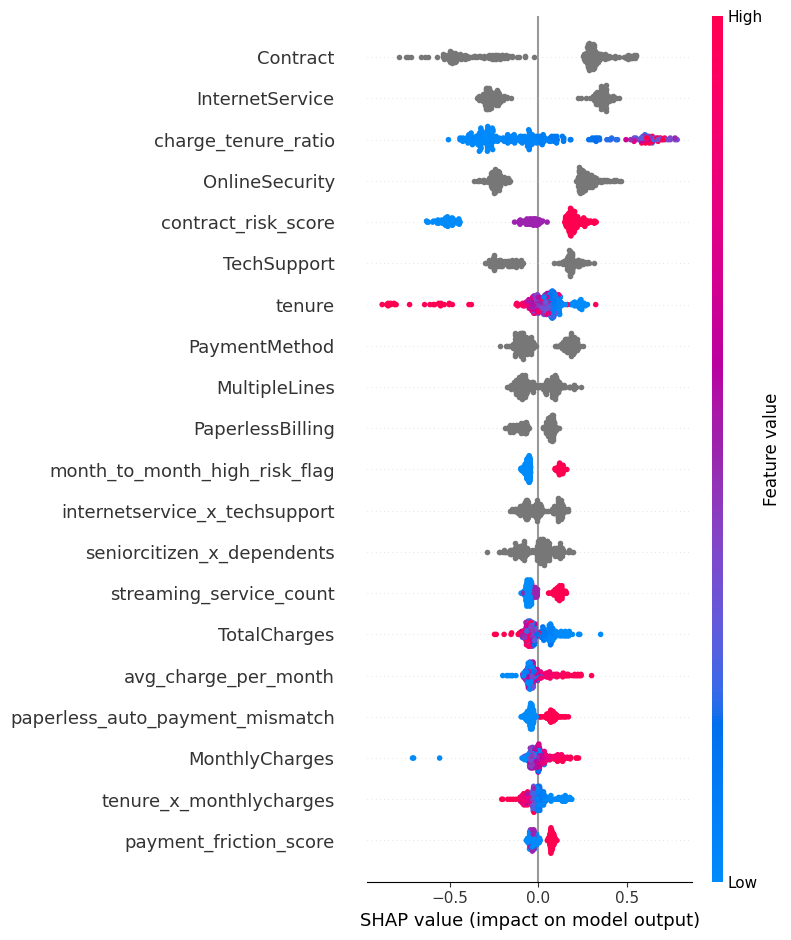


Top 20 features by mean |SHAP|:


,feature,mean_abs_shap
0,Contract,0.358439
1,InternetService,0.307766
2,charge_tenure_ratio,0.289769
3,OnlineSecurity,0.261468
4,contract_risk_score,0.241316
5,TechSupport,0.192591
6,tenure,0.126844
7,PaymentMethod,0.123570
8,MultipleLines,0.090976
9,PaperlessBilling,0.081894


In [ ]:


import shap
import matplotlib.pyplot as plt

# Rebuild clean CatBoost-ready data
X_dev_cat_shap = X_dev_model.copy()
X_test_cat_shap = X_test_model.copy()

for col in final_categorical_cols:
    X_dev_cat_shap[col] = X_dev_cat_shap[col].astype(str)
    X_test_cat_shap[col] = X_test_cat_shap[col].astype(str)

for col in final_numeric_cols:
    X_dev_cat_shap[col] = pd.to_numeric(X_dev_cat_shap[col], errors="coerce")
    X_test_cat_shap[col] = pd.to_numeric(X_test_cat_shap[col], errors="coerce")

cat_feature_indices_shap = [X_dev_cat_shap.columns.get_loc(col) for col in final_categorical_cols]

# Train a fresh CatBoost model for explanation
neg_count = (y_dev == 0).sum()
pos_count = (y_dev == 1).sum()
class_weights_shap = [1.0, float(neg_count / pos_count)]

cat_model_shap = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=class_weights_shap,
    random_seed=42,
    verbose=False
)

cat_model_shap.fit(
    X_dev_cat_shap,
    y_dev,
    cat_features=cat_feature_indices_shap
)

# Sample a manageable subset for SHAP
X_shap_sample = X_test_cat_shap.sample(n=min(300, len(X_test_cat_shap)), random_state=42)

# SHAP explainer
explainer = shap.TreeExplainer(cat_model_shap)
shap_values = explainer.shap_values(X_shap_sample)

print("SHAP sample shape:", X_shap_sample.shape)

# Handle binary classification output shape
if isinstance(shap_values, list):
    shap_values_to_use = shap_values[1]
else:
    shap_values_to_use = shap_values

print("SHAP values shape:", np.array(shap_values_to_use).shape)

# Global summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_use, X_shap_sample, show=False)
plt.tight_layout()
plt.show()

# Mean absolute SHAP importance table
mean_abs_shap = np.abs(shap_values_to_use).mean(axis=0)
shap_importance_df = pd.DataFrame({
    "feature": X_shap_sample.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by mean |SHAP|:")
display(shap_importance_df.head(20))

# Cell 34: Select high-risk customers and inspect local SHAP explanations

In [ ]:


# Build a local explanation dataframe from the test set
local_explain_df = X_test_cat_shap.copy().reset_index(drop=True)
local_explain_df["y_true"] = y_test.reset_index(drop=True)
local_explain_df["stack_calibrated_probability"] = y_test_prob_stack_cal
local_explain_df["final_pred_at_023"] = y_test_pred_final

# Select top high-risk predicted churn customers
high_risk_cases = (
    local_explain_df[local_explain_df["final_pred_at_023"] == 1]
    .sort_values("stack_calibrated_probability", ascending=False)
    .head(5)
    .copy()
)

print("Selected high-risk cases:")
display(
    high_risk_cases[
        [
            "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
            "InternetService", "OnlineSecurity", "TechSupport", "Contract",
            "PaymentMethod", "MonthlyCharges", "TotalCharges",
            "stack_calibrated_probability", "y_true"
        ]
    ]
)

# Align SHAP sample index to original rows for local plots
shap_sample_with_index = X_shap_sample.copy()
shap_sample_with_index["__orig_index__"] = X_shap_sample.index

selected_local_indices = []
for idx in high_risk_cases.index.tolist():
    if idx in shap_sample_with_index["__orig_index__"].values:
        selected_local_indices.append(idx)

print("\nHigh-risk cases present in SHAP sample:", selected_local_indices)

# Show up to 3 local waterfall plots if present in SHAP sample
shown = 0
for idx in selected_local_indices:
    shap_pos = list(shap_sample_with_index["__orig_index__"].values).index(idx)

    print(f"\nLocal SHAP explanation for test row index: {idx}")
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        shap_values_to_use[shap_pos],
        features=X_shap_sample.iloc[shap_pos],
        feature_names=X_shap_sample.columns.tolist(),
        max_display=12
    )
    shown += 1
    if shown >= 3:
        break

Selected high-risk cases:


,gender,SeniorCitizen,Partner,Dependents,tenure,InternetService,OnlineSecurity,TechSupport,Contract,PaymentMethod,MonthlyCharges,TotalCharges,stack_calibrated_probability,y_true
1221,Male,0,No,No,1,Fiber optic,No,No,Month-to-month,Electronic check,95.45,95.45,1.000000,1
1090,Male,1,Yes,No,1,Fiber optic,No,No,Month-to-month,Electronic check,95.10,95.10,1.000000,1
1109,Female,1,No,No,1,Fiber optic,No,No,Month-to-month,Electronic check,85.05,85.05,0.965574,1
710,Female,0,No,No,1,Fiber optic,No,No,Month-to-month,Mailed check,95.65,95.65,0.945788,1
1259,Female,0,No,No,1,Fiber optic,No,No,Month-to-month,Electronic check,77.15,77.15,0.900333,1



High-risk cases present in SHAP sample: []


# Cell 35: Direct local SHAP explanations for selected high-risk cases (fixed index alignment)

Direct local SHAP case indices: [1221, 1090, 1109, 710, 1259]
Local case shape: (5, 42)
Local SHAP values shape: (5, 42)

Local SHAP explanation for test row index: 1221


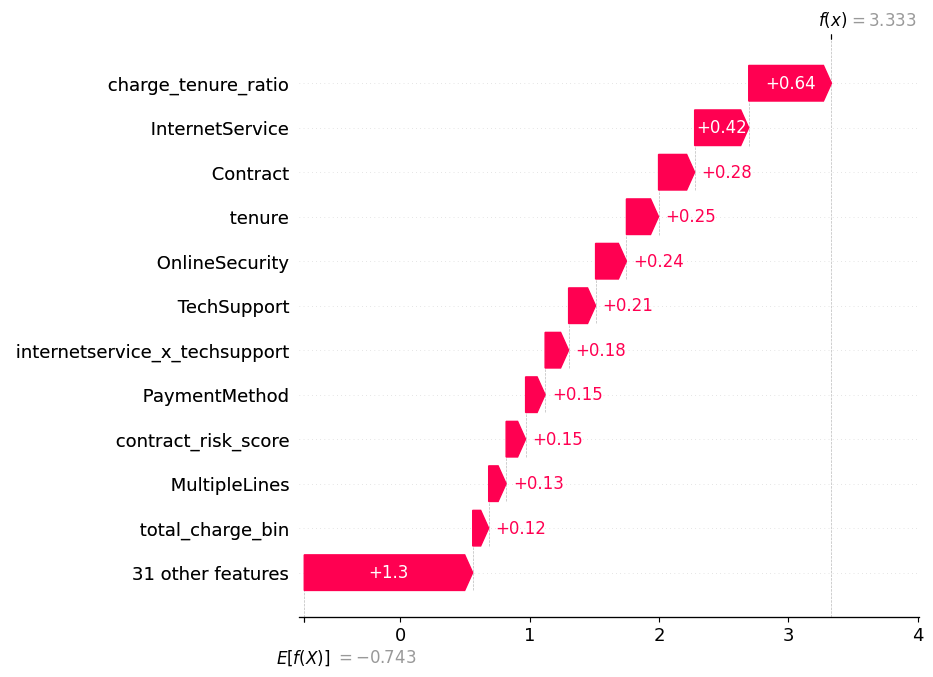


Local SHAP explanation for test row index: 1090


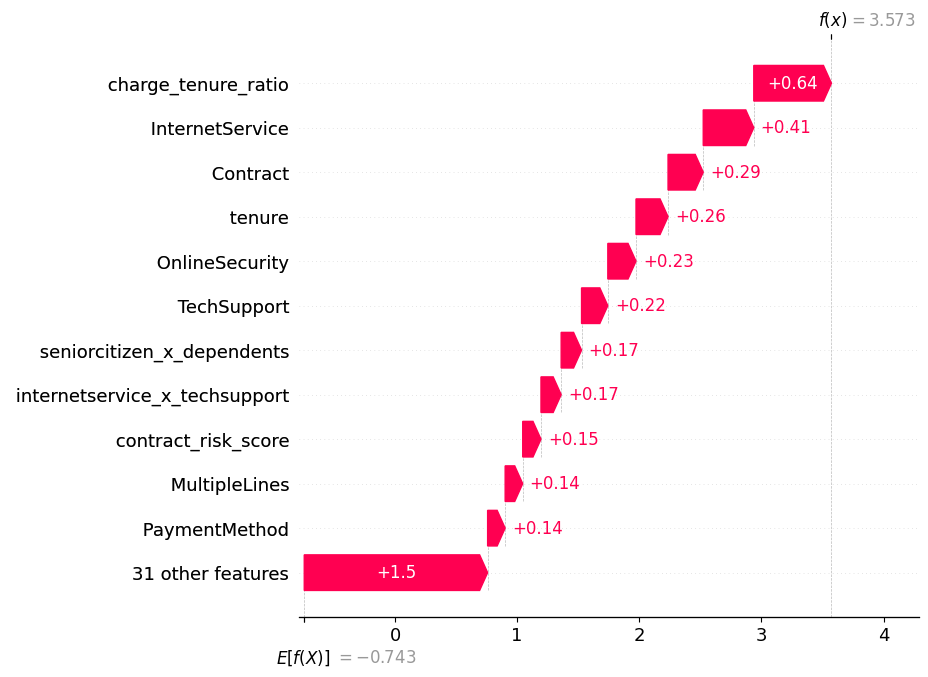


Local SHAP explanation for test row index: 1109


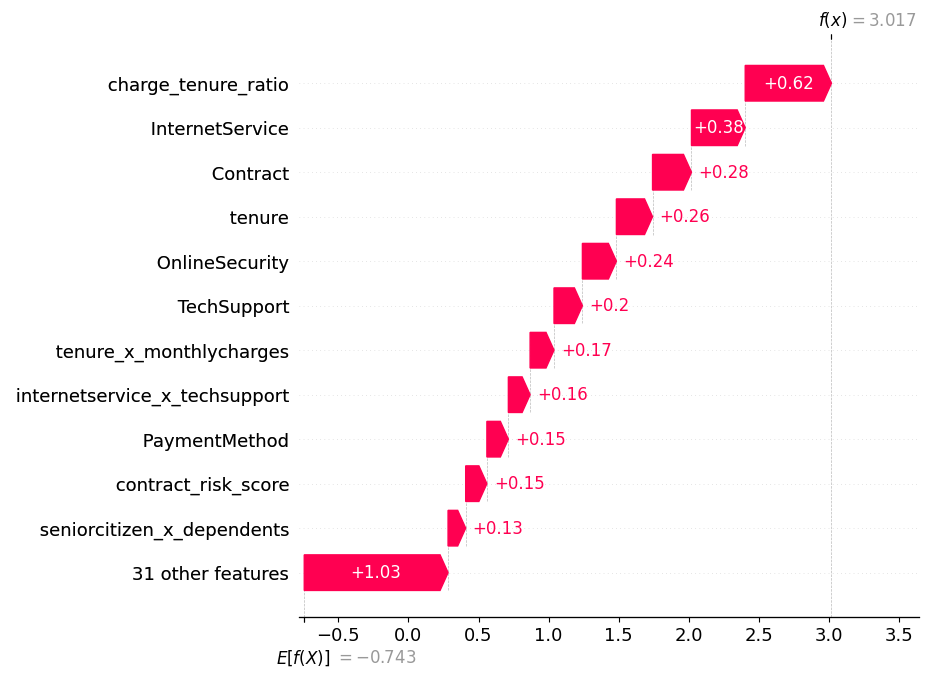


Top positive SHAP contributors for selected high-risk cases:


,feature,feature_value,shap_value,test_row_index
0,charge_tenure_ratio,95.45,0.639662,1221
1,InternetService,Fiber optic,0.418031,1221
2,Contract,Month-to-month,0.279141,1221
3,charge_tenure_ratio,95.1,0.635855,1090
4,InternetService,Fiber optic,0.413920,1090
5,Contract,Month-to-month,0.288008,1090
6,charge_tenure_ratio,85.05,0.615045,1109
7,InternetService,Fiber optic,0.383275,1109
8,Contract,Month-to-month,0.277716,1109
9,charge_tenure_ratio,95.65,0.675859,710


In [ ]:


# Reset index so it matches high_risk_cases / local_explain_df indexing
X_test_cat_shap_reset = X_test_cat_shap.reset_index(drop=True).copy()

# Use the exact selected rows for direct local SHAP
high_risk_case_indices = high_risk_cases.index.tolist()
X_local_cases = X_test_cat_shap_reset.loc[high_risk_case_indices].copy()

print("Direct local SHAP case indices:", high_risk_case_indices)
print("Local case shape:", X_local_cases.shape)

# Compute SHAP values directly on these selected cases
local_shap_values = explainer.shap_values(X_local_cases)

if isinstance(local_shap_values, list):
    local_shap_values_to_use = local_shap_values[1]
else:
    local_shap_values_to_use = local_shap_values

print("Local SHAP values shape:", np.array(local_shap_values_to_use).shape)

# Show up to 3 local waterfall plots
for i, idx in enumerate(high_risk_case_indices[:3]):
    print(f"\nLocal SHAP explanation for test row index: {idx}")
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value,
        local_shap_values_to_use[i],
        features=X_local_cases.iloc[i],
        feature_names=X_local_cases.columns.tolist(),
        max_display=12
    )

# Build top positive feature contribution table for all selected cases
top_local_rows = []

for i, idx in enumerate(high_risk_case_indices):
    row_vals = local_shap_values_to_use[i]
    row_features = X_local_cases.iloc[i]

    temp_df = pd.DataFrame({
        "feature": X_local_cases.columns,
        "feature_value": row_features.values,
        "shap_value": row_vals
    }).sort_values("shap_value", ascending=False)

    top3 = temp_df.head(3).copy()
    top3["test_row_index"] = idx
    top_local_rows.append(top3)

top_local_summary = pd.concat(top_local_rows, ignore_index=True)

print("\nTop positive SHAP contributors for selected high-risk cases:")
display(top_local_summary)

# Cell 36: Counterfactual recommendation engine using actionable intervention simulation

In [ ]:


# We will simulate realistic actionable changes on selected high-risk cases
# and score them using the full final pipeline:
# base models -> stacked ensemble -> isotonic calibration

# Helper: transform a modified case into stacked test features and calibrated probability
def get_base_model_probabilities_for_cases(case_df_raw):
    """
    Returns a DataFrame with probabilities from the 5 base models:
    CatBoost, XGBoost, LightGBM, TabNet, FT-Transformer
    """
    # ---------- 1) Feature engineering ----------
    case_fe = add_engineered_features(case_df_raw.copy())

    # ---------- 2) KMeans segment ----------
    case_cluster_num = cluster_imputer.transform(case_fe[cluster_features])
    case_cluster_scaled = cluster_scaler.transform(case_cluster_num)
    case_fe["customer_segment_kmeans"] = kmeans.predict(case_cluster_scaled)

    # ---------- 3) Final modeled data ----------
    case_model = case_fe.drop(columns=["customerID"]).copy()

    # ---------- 4) XGBoost probability ----------
    xgb_prob = xgb_pipeline.predict_proba(case_model)[:, 1]

    # ---------- 5) LightGBM probability ----------
    lgb_prob = lgb_pipeline.predict_proba(case_model)[:, 1]

    # ---------- 6) CatBoost probability ----------
    case_cat = case_model.copy()
    for col in final_categorical_cols:
        case_cat[col] = case_cat[col].astype(str)
    for col in final_numeric_cols:
        case_cat[col] = pd.to_numeric(case_cat[col], errors="coerce")
    cat_prob = cat_model.predict_proba(case_cat)[:, 1]

    # ---------- 7) TabNet probability ----------
    case_num_tab = pd.DataFrame(
        num_imputer_tabnet.transform(case_model[final_numeric_cols]),
        columns=final_numeric_cols,
        index=case_model.index
    )
    case_cat_tab = pd.DataFrame(
        cat_imputer_tabnet.transform(case_model[final_categorical_cols]),
        columns=final_categorical_cols,
        index=case_model.index
    )

    for col in final_categorical_cols:
        le = label_encoders_tabnet[col]
        vals = case_cat_tab[col].astype(str)

        unseen = sorted(set(vals.unique()) - set(le.classes_))
        if unseen:
            le_classes_extended = np.concatenate([le.classes_, np.array(unseen, dtype=object)])
            le.classes_ = le_classes_extended

        case_cat_tab[col] = le.transform(vals)

    case_tab_final = pd.concat([case_num_tab, case_cat_tab], axis=1)
    case_tab_final = case_tab_final[X_train_tabnet_final.columns]

    case_tab_np = case_tab_final.values.astype(np.float32)
    tabnet_prob = tabnet_model.predict_proba(case_tab_np)[:, 1]

    # ---------- 8) FT-Transformer probability ----------
    case_ft = case_model.copy()
    case_ft["Churn_Binary"] = 0  # dummy target for predict interface
    case_ft[final_numeric_cols] = ft_numeric_imputer.transform(case_ft[final_numeric_cols])

    ft_pred_case = ft_model.predict(case_ft)

    ft_prob_col_candidates = [
        "Churn_Binary_1_probability",
        "1_probability",
        "probability_1",
        "prediction_probability",
        "Churn_Binary_probability",
        "Churn_Binary_1_probs",
        "1_probabilities",
    ]

    ft_prob_col = None
    for c in ft_prob_col_candidates:
        if c in ft_pred_case.columns:
            ft_prob_col = c
            break

    if ft_prob_col is None:
        numeric_cols_pred = ft_pred_case.select_dtypes(include=[np.number]).columns.tolist()
        candidate_numeric = [c for c in numeric_cols_pred if c.lower() not in ["prediction", "predictions", "churn_binary"]]
        if len(candidate_numeric) == 0:
            raise ValueError("Could not identify FT probability column in counterfactual engine.")
        ft_prob_col = candidate_numeric[-1]

    ft_prob = ft_pred_case[ft_prob_col].values.astype(float)

    # ---------- 9) Build stack ----------
    stack_case = pd.DataFrame({
        "catboost": cat_prob,
        "xgboost": xgb_prob,
        "lightgbm": lgb_prob,
        "tabnet": tabnet_prob,
        "ft_transformer": ft_prob,
    })

    return stack_case


def get_final_calibrated_probability(case_df_raw):
    stack_case = get_base_model_probabilities_for_cases(case_df_raw)
    final_prob = iso_calibrator.predict_proba(stack_case)[:, 1]
    return final_prob


# Selected high-risk original raw rows from test set
X_test_raw_reset = X_test.reset_index(drop=True).copy()
selected_case_raw = X_test_raw_reset.loc[high_risk_case_indices].copy()

# Baseline probabilities
baseline_probs = get_final_calibrated_probability(selected_case_raw)

# Define realistic intervention actions
def apply_intervention(case_df, intervention_name):
    mod = case_df.copy()

    if intervention_name == "contract_to_one_year":
        mod["Contract"] = "One year"

    elif intervention_name == "contract_to_two_year":
        mod["Contract"] = "Two year"

    elif intervention_name == "add_tech_support":
        mod.loc[mod["InternetService"].isin(["DSL", "Fiber optic"]), "TechSupport"] = "Yes"

    elif intervention_name == "add_online_security":
        mod.loc[mod["InternetService"].isin(["DSL", "Fiber optic"]), "OnlineSecurity"] = "Yes"

    elif intervention_name == "switch_payment_auto":
        mod["PaymentMethod"] = "Bank transfer (automatic)"

    elif intervention_name == "reduce_monthly_charge_10pct":
        mod["MonthlyCharges"] = mod["MonthlyCharges"] * 0.90

    elif intervention_name == "bundle_support_security":
        mod.loc[mod["InternetService"].isin(["DSL", "Fiber optic"]), "TechSupport"] = "Yes"
        mod.loc[mod["InternetService"].isin(["DSL", "Fiber optic"]), "OnlineSecurity"] = "Yes"

    else:
        raise ValueError(f"Unknown intervention: {intervention_name}")

    return mod


interventions = [
    "contract_to_one_year",
    "contract_to_two_year",
    "add_tech_support",
    "add_online_security",
    "switch_payment_auto",
    "reduce_monthly_charge_10pct",
    "bundle_support_security",
]

counterfactual_rows = []

for intervention in interventions:
    modified_cases = apply_intervention(selected_case_raw, intervention)
    modified_probs = get_final_calibrated_probability(modified_cases)

    for i, idx in enumerate(high_risk_case_indices):
        counterfactual_rows.append({
            "test_row_index": idx,
            "intervention": intervention,
            "baseline_probability": baseline_probs[i],
            "new_probability": modified_probs[i],
            "probability_reduction": baseline_probs[i] - modified_probs[i]
        })

counterfactual_df = pd.DataFrame(counterfactual_rows)

print("Counterfactual intervention results:")
display(
    counterfactual_df.sort_values(
        ["test_row_index", "probability_reduction"],
        ascending=[True, False]
    )
)

best_intervention_per_case = (
    counterfactual_df.sort_values(
        ["test_row_index", "probability_reduction"],
        ascending=[True, False]
    )
    .groupby("test_row_index", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

print("\nBest intervention per selected high-risk case:")
display(best_intervention_per_case)

Counterfactual intervention results:


,test_row_index,intervention,baseline_probability,new_probability,probability_reduction
8,710,contract_to_two_year,0.892641,0.316304,0.576337
3,710,contract_to_one_year,0.892641,0.525889,0.366751
33,710,bundle_support_security,0.892641,0.570244,0.322397
13,710,add_tech_support,0.892641,0.755791,0.136849
18,710,add_online_security,0.892641,0.772001,0.120640
28,710,reduce_monthly_charge_10pct,0.892641,0.876954,0.015686
23,710,switch_payment_auto,0.892641,0.894154,-0.001513
6,1090,contract_to_two_year,0.947641,0.550200,0.397440
1,1090,contract_to_one_year,0.947641,0.772001,0.175640
31,1090,bundle_support_security,0.947641,0.772001,0.175640



Best intervention per selected high-risk case:


,test_row_index,intervention,baseline_probability,new_probability,probability_reduction
0,710,contract_to_two_year,0.892641,0.316304,0.576337
1,1090,contract_to_two_year,0.947641,0.550200,0.397440
2,1109,contract_to_two_year,0.895671,0.484790,0.410881
3,1221,contract_to_two_year,0.900333,0.567545,0.332788
4,1259,contract_to_two_year,0.876954,0.436385,0.440570


# Cell 37: Final publication-style summary tables

In [ ]:


# 1) Main model comparison
final_model_summary = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_results},
    {"Model": "Random Forest", **rf_results},
    {"Model": "XGBoost", **xgb_results},
    {"Model": "LightGBM", **lgb_results},
    {"Model": "CatBoost", **cat_results},
    {"Model": "TabNet", **tabnet_results},
    {"Model": "FT-Transformer", **ft_results},
    {"Model": "Stacked Ensemble", **stack_results},
    {"Model": "Calibrated Stacked Ensemble (0.50 threshold)", **stack_cal_results},
    {"Model": "Final Calibrated Stacked Ensemble (0.23 threshold)", **final_threshold_results},
])

final_model_summary = final_model_summary[
    ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"] + ([ "Brier" ] if "Brier" in final_model_summary.columns else [])
]

print("Final model summary:")
display(final_model_summary)

# 2) Uncertainty summary
uncertainty_summary_table = tier_summary.reset_index()
print("\nUncertainty tier summary:")
display(uncertainty_summary_table)

# 3) Best business policy
print("\nBest business targeting policy:")
display(pd.DataFrame([best_policy]))

# 4) Best counterfactual per selected case
print("\nBest counterfactual intervention per selected high-risk case:")
display(best_intervention_per_case)

# 5) Top SHAP features
print("\nTop 15 global SHAP features:")
display(shap_importance_df.head(15))

Final model summary:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,Brier
0,Logistic Regression,0.745209,0.512998,0.791444,0.622503,0.846284,0.662659,NaN
1,Random Forest,0.773598,0.569620,0.601604,0.585176,0.836180,0.642031,NaN
2,XGBoost,0.756565,0.528029,0.780749,0.629989,0.841167,0.654497,NaN
3,LightGBM,0.763662,0.540755,0.727273,0.620296,0.834411,0.633802,NaN
4,CatBoost,0.760823,0.533698,0.783422,0.634886,0.845523,0.662379,NaN
5,TabNet,0.731725,0.496721,0.810160,0.615854,0.835850,0.650450,NaN
6,FT-Transformer,0.781405,0.757812,0.259358,0.386454,0.846896,0.661729,NaN
7,Stacked Ensemble,0.757275,0.528881,0.783422,0.631466,0.846292,0.661883,NaN
8,Calibrated Stacked Ensemble (0.50 threshold),0.807665,0.674576,0.532086,0.594918,0.845781,0.656794,0.134754
9,Final Calibrated Stacked Ensemble (0.23 thresh...,0.743790,0.510638,0.834225,0.633503,0.845781,0.656794,0.134754



Uncertainty tier summary:


,uncertainty_tier,count,actual_churn_rate,avg_predicted_probability,min_probability,max_probability
0,confident_churn,107,0.813084,0.833226,0.710337,1.000000
1,uncertain,819,0.330891,0.329229,0.100794,0.690135
2,confident_non_churn,483,0.033126,0.032577,0.003086,0.096995



Best business targeting policy:


,top_k_percent,k_customers,tp,fp,fn,tn,precision_at_k,recall_at_k,total_cost,total_benefit,net_utility
0,0.5,704.0,326.0,378.0,48.0,657.0,0.463068,0.871658,704.0,1630.0,926.0



Best counterfactual intervention per selected high-risk case:


,test_row_index,intervention,baseline_probability,new_probability,probability_reduction
0,710,contract_to_two_year,0.892641,0.316304,0.576337
1,1090,contract_to_two_year,0.947641,0.550200,0.397440
2,1109,contract_to_two_year,0.895671,0.484790,0.410881
3,1221,contract_to_two_year,0.900333,0.567545,0.332788
4,1259,contract_to_two_year,0.876954,0.436385,0.440570



Top 15 global SHAP features:


,feature,mean_abs_shap
0,Contract,0.358439
1,InternetService,0.307766
2,charge_tenure_ratio,0.289769
3,OnlineSecurity,0.261468
4,contract_risk_score,0.241316
5,TechSupport,0.192591
6,tenure,0.126844
7,PaymentMethod,0.123570
8,MultipleLines,0.090976
9,PaperlessBilling,0.081894


# PAPER-READY FIGURE PACK GENERATOR (300 DPI)

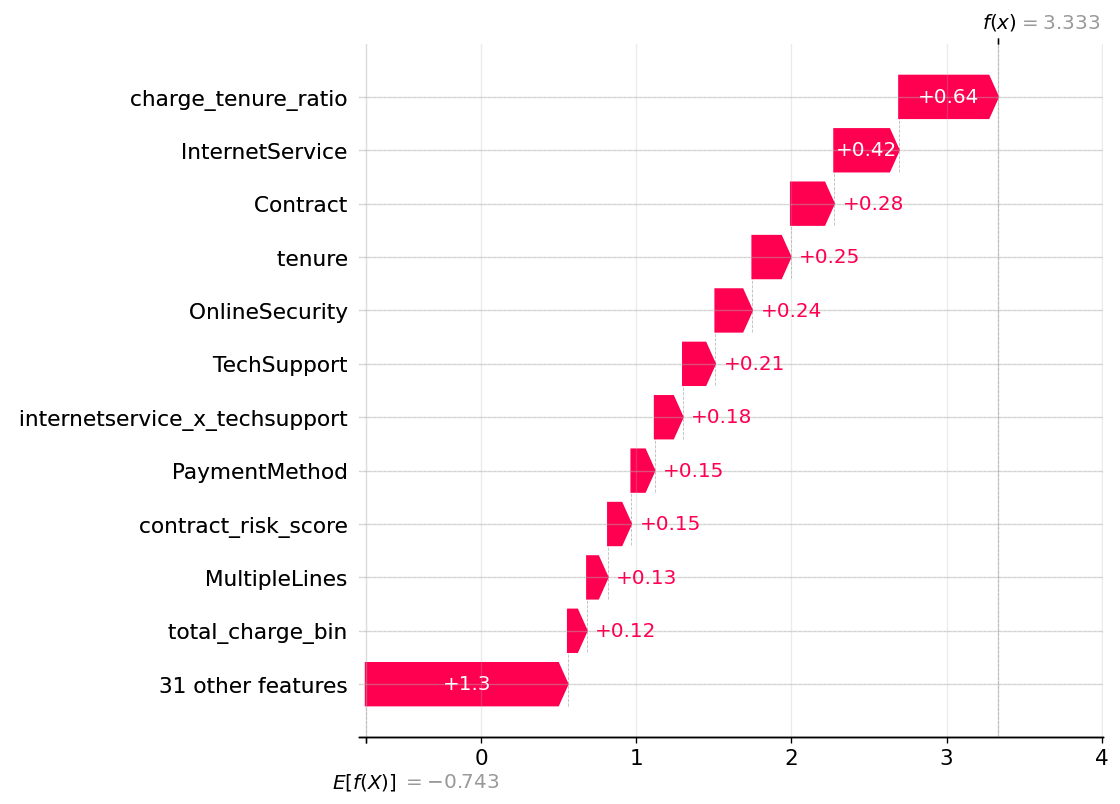

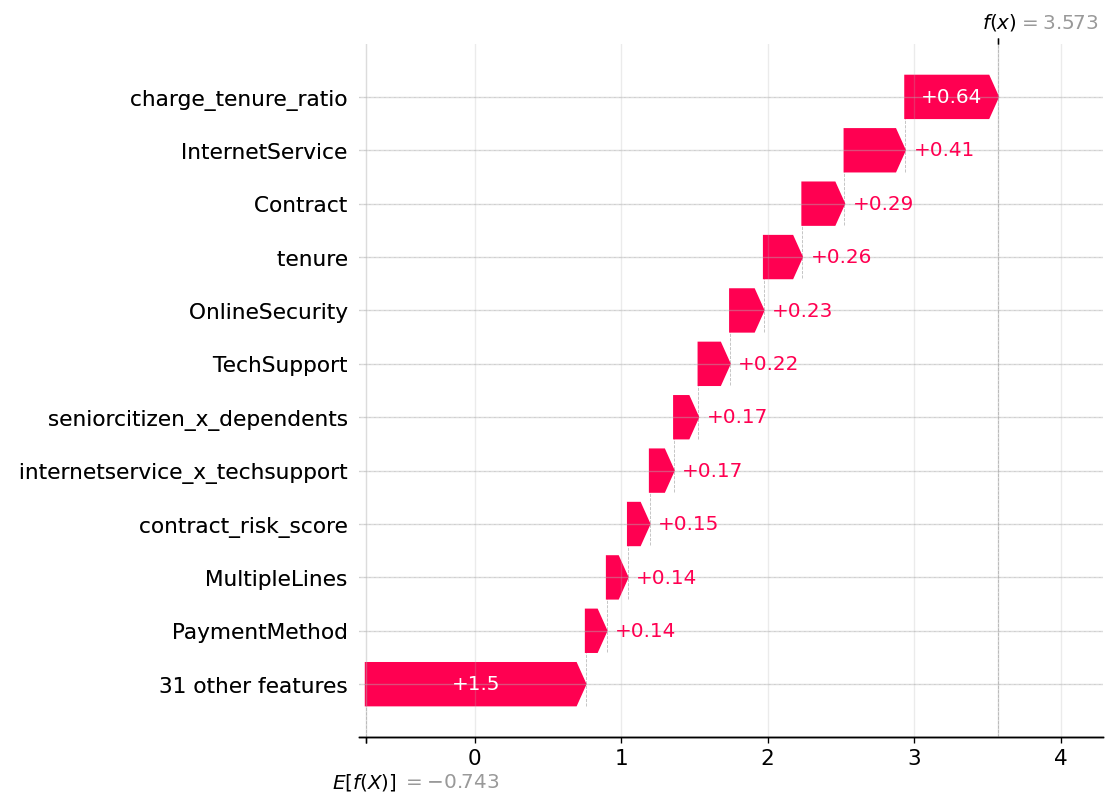

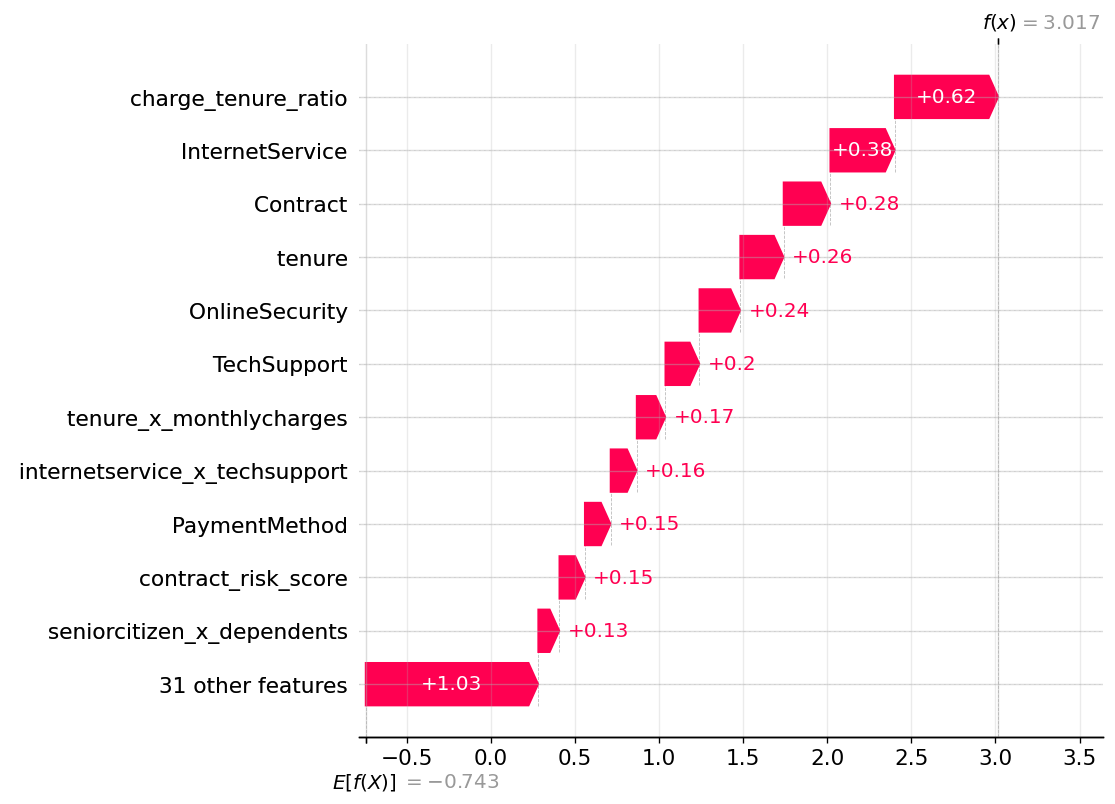

All paper-ready figures generated.
Figure folder: /kaggle/working/paper_figures
ZIP bundle:   /kaggle/working/paper_figures_bundle.zip
Total files:  41

Generated files:
- fig01_class_distribution.png
- fig02_churn_rate_by_contract.png
- fig03_churn_rate_by_internetservice.png
- fig04_churn_rate_by_paymentmethod.png
- fig05_churn_rate_by_techsupport.png
- fig06_churn_rate_by_onlinesecurity.png
- fig07_boxplot_tenure_by_churn.png
- fig08_boxplot_monthlycharges_by_churn.png
- fig09_boxplot_totalcharges_by_churn.png
- fig10_density_tenure_by_churn.png
- fig11_density_monthlycharges_by_churn.png
- fig12_density_totalcharges_by_churn.png
- fig13_correlation_heatmap.png
- fig14_model_comparison_roc_auc.png
- fig15_model_comparison_pr_auc.png
- fig16_model_comparison_f1.png
- fig17_grouped_model_metrics.png
- fig18_roc_curves.png
- fig19_precision_recall_curves.png
- fig20_calibration_curves.png
- fig21_brier_score_comparison.png
- fig22_threshold_optimization.png
- fig23_threshold_vs_predict

In [ ]:
# ============================================

# ============================================

import os
import zipfile
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from sklearn.metrics import (
    roc_curve, precision_recall_curve, auc
)
from sklearn.calibration import calibration_curve

# -----------------------------
# 0) Output setup
# -----------------------------
FIG_DIR = Path("/kaggle/working/paper_figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = Path("/kaggle/working/paper_figures_bundle.zip")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "figure.titlesize": 14,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

generated_files = []

def save_current_fig(filename, tight=True):
    path = FIG_DIR / filename
    if tight:
        plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    generated_files.append(path.name)
    plt.close()

def save_manifest():
    manifest = pd.DataFrame({"filename": generated_files})
    manifest.to_csv(FIG_DIR / "figure_manifest.csv", index=False)
    if "figure_manifest.csv" not in generated_files:
        generated_files.append("figure_manifest.csv")

def safe_barplot_from_series(series, title, xlabel, ylabel, filename, rotation=0):
    plt.figure(figsize=(7, 4.5))
    series.plot(kind="bar")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation, ha="right" if rotation else "center")
    save_current_fig(filename)

def plot_churn_rate_bar(data, col, filename):
    temp = (
        data.groupby(col)["Churn"]
        .apply(lambda s: (s == "Yes").mean())
        .sort_values(ascending=False)
    )
    counts = data[col].value_counts().reindex(temp.index)
    labels = [f"{idx}\n(n={counts[idx]})" for idx in temp.index]

    plt.figure(figsize=(8, 5))
    plt.bar(labels, temp.values)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=25, ha="right")
    plt.ylim(0, min(1.0, max(temp.values) * 1.2))
    for i, v in enumerate(temp.values):
        plt.text(i, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
    save_current_fig(filename)

def plot_box_by_churn(data, col, filename):
    groups = [
        data.loc[data["Churn"] == "No", col].dropna(),
        data.loc[data["Churn"] == "Yes", col].dropna()
    ]
    plt.figure(figsize=(6, 4.5))
    plt.boxplot(groups, tick_labels=["No", "Yes"], showfliers=False)
    plt.title(f"{col} Distribution by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    save_current_fig(filename)

def plot_hist_by_churn(data, col, filename, bins=30):
    plt.figure(figsize=(7, 4.5))
    plt.hist(data.loc[data["Churn"] == "No", col].dropna(), bins=bins, alpha=0.6, label="No", density=True)
    plt.hist(data.loc[data["Churn"] == "Yes", col].dropna(), bins=bins, alpha=0.6, label="Yes", density=True)
    plt.title(f"{col} Density by Churn")
    plt.xlabel(col)
    plt.ylabel("Density")
    plt.legend(frameon=False)
    save_current_fig(filename)

# -----------------------------
# 1) Data understanding figures
# -----------------------------
if "df_clean" not in globals():
    raise RuntimeError("df_clean is not found. Run the earlier notebook cells first.")

safe_barplot_from_series(
    df_clean["Churn"].value_counts().reindex(["No", "Yes"]),
    title="Figure 1. Class Distribution of Churn",
    xlabel="Churn",
    ylabel="Customer Count",
    filename="fig01_class_distribution.png"
)

for i, col in enumerate(["Contract", "InternetService", "PaymentMethod", "TechSupport", "OnlineSecurity"], start=2):
    plot_churn_rate_bar(df_clean, col, f"fig{i:02d}_churn_rate_by_{col.lower()}.png")

for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"], start=7):
    plot_box_by_churn(df_clean, col, f"fig{i:02d}_boxplot_{col.lower()}_by_churn.png")

for i, col in enumerate(["tenure", "MonthlyCharges", "TotalCharges"], start=10):
    plot_hist_by_churn(df_clean, col, f"fig{i:02d}_density_{col.lower()}_by_churn.png")

try:
    corr_df = X_dev_fe[[
        "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
        "avg_charge_per_month", "charge_tenure_ratio",
        "service_count", "support_service_count",
        "streaming_service_count", "contract_risk_score",
        "payment_friction_score", "tenure_x_monthlycharges",
        "support_bundle_x_monthlycharges", "customer_segment_kmeans"
    ]].copy()
    corr = corr_df.corr(numeric_only=True)

    plt.figure(figsize=(11, 8))
    im = plt.imshow(corr, aspect="auto")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Figure 13. Correlation Heatmap of Numeric and Engineered Features")
    save_current_fig("fig13_correlation_heatmap.png")
except Exception as e:
    print("Skipped correlation heatmap:", e)

# -----------------------------
# 2) Model comparison figures
# -----------------------------
if "results_summary" not in globals():
    raise RuntimeError("results_summary is not found. Run the model comparison cell first.")

results_plot_df = results_summary.copy()

roc_bar = results_plot_df.set_index("Model")["ROC_AUC"].sort_values(ascending=False)
safe_barplot_from_series(
    roc_bar,
    title="Figure 14. ROC-AUC Comparison Across Models",
    xlabel="Model",
    ylabel="ROC-AUC",
    filename="fig14_model_comparison_roc_auc.png",
    rotation=35
)

pr_bar = results_plot_df.set_index("Model")["PR_AUC"].sort_values(ascending=False)
safe_barplot_from_series(
    pr_bar,
    title="Figure 15. PR-AUC Comparison Across Models",
    xlabel="Model",
    ylabel="PR-AUC",
    filename="fig15_model_comparison_pr_auc.png",
    rotation=35
)

f1_bar = results_plot_df.set_index("Model")["F1"].sort_values(ascending=False)
safe_barplot_from_series(
    f1_bar,
    title="Figure 16. F1-Score Comparison Across Models",
    xlabel="Model",
    ylabel="F1-Score",
    filename="fig16_model_comparison_f1.png",
    rotation=35
)

metrics_for_grouped = results_plot_df.set_index("Model")[["Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"]]
plt.figure(figsize=(12, 6))
metrics_for_grouped.plot(kind="bar", ax=plt.gca())
plt.title("Figure 17. Comparative Model Performance Across Key Metrics")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=35, ha="right")
plt.legend(frameon=False, ncol=5, loc="upper center", bbox_to_anchor=(0.5, 1.18))
save_current_fig("fig17_grouped_model_metrics.png")

# -----------------------------
# 3) ROC and PR curves
# -----------------------------
required_prob_vars = [
    ("Logistic Regression", "y_test_prob_lr"),
    ("CatBoost", "y_test_prob_cat"),
    ("XGBoost", "y_test_prob_xgb"),
    ("FT-Transformer", "y_test_prob_ft"),
    ("Stacked Ensemble", "y_test_prob_stack"),
    ("Calibrated Stacked Ensemble", "y_test_prob_stack_cal"),
]
for _, var_name in required_prob_vars:
    if var_name not in globals():
        raise RuntimeError(f"{var_name} is not found. Run the earlier model cells first.")

plt.figure(figsize=(7.5, 6))
for model_name, var_name in required_prob_vars:
    probs = globals()[var_name]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.title("Figure 18. ROC Curves for Selected Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(frameon=False, loc="lower right")
save_current_fig("fig18_roc_curves.png")

plt.figure(figsize=(7.5, 6))
for model_name, var_name in required_prob_vars:
    probs = globals()[var_name]
    prec, rec, _ = precision_recall_curve(y_test, probs)
    pr_auc_val = auc(rec, prec)
    plt.plot(rec, prec, label=f"{model_name} (AUC={pr_auc_val:.3f})")
plt.title("Figure 19. Precision-Recall Curves for Selected Models")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(frameon=False, loc="lower left")
save_current_fig("fig19_precision_recall_curves.png")

# -----------------------------
# 4) Calibration and threshold figures
# -----------------------------
cal_needed = [
    "stack_y_cal", "stack_y_cal_prob_uncal",
    "stack_y_cal_prob_platt", "stack_y_cal_prob_iso",
    "calibration_results", "threshold_df"
]
for v in cal_needed:
    if v not in globals():
        raise RuntimeError(f"{v} is not found. Run the calibration / threshold cells first.")

plt.figure(figsize=(7, 6))
for label, probs in [
    ("Uncalibrated", stack_y_cal_prob_uncal),
    ("Platt", stack_y_cal_prob_platt),
    ("Isotonic", stack_y_cal_prob_iso),
]:
    frac_pos, mean_pred = calibration_curve(stack_y_cal, probs, n_bins=10, strategy="uniform")
    plt.plot(mean_pred, frac_pos, marker="o", label=label)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Perfect calibration")
plt.title("Figure 20. Calibration Curves for the Stacked Ensemble")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Positive Fraction")
plt.legend(frameon=False)
save_current_fig("fig20_calibration_curves.png")

brier_series = calibration_results.set_index("Method")["Brier"].sort_values()
safe_barplot_from_series(
    brier_series,
    title="Figure 21. Brier Score Comparison for Calibration Methods",
    xlabel="Calibration Method",
    ylabel="Brier Score",
    filename="fig21_brier_score_comparison.png"
)

plt.figure(figsize=(8, 5.5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(0.23, linestyle="--", linewidth=1.2, label="Selected threshold = 0.23")
plt.title("Figure 22. Threshold Optimization for the Calibrated Stacked Ensemble")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Value")
plt.legend(frameon=False)
save_current_fig("fig22_threshold_optimization.png")

plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["predicted_positive_count"])
plt.axvline(0.23, linestyle="--", linewidth=1.2, label="Selected threshold = 0.23")
plt.title("Figure 23. Predicted Positive Count Across Thresholds")
plt.xlabel("Classification Threshold")
plt.ylabel("Predicted Positive Count")
plt.legend(frameon=False)
save_current_fig("fig23_threshold_vs_predicted_positive_count.png")

# -----------------------------
# 5) Uncertainty and business figures
# -----------------------------
for v in ["uncertainty_df", "tier_summary", "business_policy_df", "business_df"]:
    if v not in globals():
        raise RuntimeError(f"{v} is not found. Run the uncertainty/business cells first.")

safe_barplot_from_series(
    uncertainty_df["uncertainty_tier"].value_counts(),
    title="Figure 24. Uncertainty Tier Counts",
    xlabel="Tier",
    ylabel="Customer Count",
    filename="fig24_uncertainty_tier_counts.png"
)

tier_churn_rate = tier_summary["actual_churn_rate"].sort_values(ascending=False)
safe_barplot_from_series(
    tier_churn_rate,
    title="Figure 25. Actual Churn Rate by Uncertainty Tier",
    xlabel="Tier",
    ylabel="Actual Churn Rate",
    filename="fig25_uncertainty_tier_churn_rate.png"
)

plt.figure(figsize=(8, 5))
x_labels = (business_policy_df["top_k_percent"] * 100).astype(int).astype(str) + "%"
plt.plot(x_labels, business_policy_df["net_utility"], marker="o")
plt.title("Figure 26. Net Utility Across Top-k Targeting Policies")
plt.xlabel("Top-k Targeting Policy")
plt.ylabel("Net Utility")
save_current_fig("fig26_business_net_utility.png")

plt.figure(figsize=(8, 5))
plt.plot(x_labels, business_policy_df["precision_at_k"], marker="o", label="Precision@k")
plt.plot(x_labels, business_policy_df["recall_at_k"], marker="o", label="Recall@k")
plt.title("Figure 27. Precision@k and Recall@k Across Targeting Policies")
plt.xlabel("Top-k Targeting Policy")
plt.ylabel("Metric Value")
plt.legend(frameon=False)
save_current_fig("fig27_precision_recall_at_k.png")

business_sorted = business_df.copy().sort_values("churn_probability", ascending=False).reset_index(drop=True)
cum_churn = business_sorted["y_true"].cumsum() / business_sorted["y_true"].sum()
cum_population = np.arange(1, len(business_sorted) + 1) / len(business_sorted)
plt.figure(figsize=(7.5, 6))
plt.plot(cum_population, cum_churn, label="Model")
plt.plot([0, 1], [0, 1], linestyle="--", label="Baseline")
plt.title("Figure 28. Cumulative Gains Chart")
plt.xlabel("Proportion of Customers Targeted")
plt.ylabel("Proportion of Actual Churners Captured")
plt.legend(frameon=False)
save_current_fig("fig28_cumulative_gains_chart.png")

# -----------------------------
# 6) SHAP explainability figures
# -----------------------------
for v in ["explainer", "shap_values_to_use", "X_shap_sample", "shap_importance_df"]:
    if v not in globals():
        raise RuntimeError(f"{v} is not found. Run the SHAP cells first.")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_to_use, X_shap_sample, show=False)
plt.title("Figure 29. SHAP Summary Plot")
save_current_fig("fig29_shap_summary_beeswarm.png", tight=False)

top15_shap = shap_importance_df.head(15).iloc[::-1]
plt.figure(figsize=(8, 6))
plt.barh(top15_shap["feature"], top15_shap["mean_abs_shap"])
plt.title("Figure 30. Top 15 Features by Mean Absolute SHAP Value")
plt.xlabel("Mean |SHAP Value|")
plt.ylabel("Feature")
save_current_fig("fig30_top15_shap_importance.png")

for fig_num, feat in zip([31, 32, 33], ["charge_tenure_ratio", "tenure", "MonthlyCharges"]):
    if feat in X_shap_sample.columns:
        feat_idx = list(X_shap_sample.columns).index(feat)
        plt.figure(figsize=(7, 5))
        x_vals = pd.to_numeric(X_shap_sample[feat], errors="coerce")
        plt.scatter(x_vals, np.array(shap_values_to_use)[:, feat_idx], alpha=0.65)
        plt.title(f"Figure {fig_num}. SHAP Dependence for {feat}")
        plt.xlabel(feat)
        plt.ylabel(f"SHAP value for {feat}")
        save_current_fig(f"fig{fig_num:02d}_shap_dependence_{feat.lower()}.png")

if all(v in globals() for v in ["local_shap_values_to_use", "X_local_cases", "high_risk_case_indices"]):
    for fig_num, i in zip([34, 35, 36], range(min(3, len(high_risk_case_indices)))):
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value,
            local_shap_values_to_use[i],
            features=X_local_cases.iloc[i],
            feature_names=X_local_cases.columns.tolist(),
            max_display=12,
        )
        plt.title(f"Figure {fig_num}. Local SHAP Waterfall Plot (Case {high_risk_case_indices[i]})")
        save_current_fig(f"fig{fig_num:02d}_local_shap_waterfall_case_{high_risk_case_indices[i]}.png", tight=False)

# -----------------------------
# 7) Counterfactual figures
# -----------------------------
for v in ["counterfactual_df", "best_intervention_per_case"]:
    if v not in globals():
        raise RuntimeError(f"{v} is not found. Run the counterfactual cell first.")

avg_cf = (
    counterfactual_df.groupby("intervention")["probability_reduction"]
    .mean()
    .sort_values(ascending=True)
)
plt.figure(figsize=(8, 5.5))
plt.barh(avg_cf.index, avg_cf.values)
plt.title("Figure 37. Average Churn Probability Reduction by Intervention")
plt.xlabel("Average Probability Reduction")
plt.ylabel("Intervention")
save_current_fig("fig37_counterfactual_avg_probability_reduction.png")

cf_pivot = counterfactual_df.pivot(index="test_row_index", columns="intervention", values="probability_reduction")
plt.figure(figsize=(10, 4.8))
im = plt.imshow(cf_pivot.values, aspect="auto")
plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(range(len(cf_pivot.columns)), cf_pivot.columns, rotation=45, ha="right")
plt.yticks(range(len(cf_pivot.index)), cf_pivot.index)
plt.title("Figure 38. Counterfactual Probability Reduction by Case and Intervention")
plt.xlabel("Intervention")
plt.ylabel("Test Row Index")
save_current_fig("fig38_counterfactual_heatmap.png")

cf_best = best_intervention_per_case.copy()
x = np.arange(len(cf_best))
width = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - width/2, cf_best["baseline_probability"], width, label="Baseline")
plt.bar(x + width/2, cf_best["new_probability"], width, label="After Best Intervention")
plt.xticks(x, cf_best["test_row_index"].astype(str))
plt.xlabel("Selected High-Risk Case")
plt.ylabel("Churn Probability")
plt.title("Figure 39. Baseline vs Best-Intervention Churn Probability")
plt.legend(frameon=False)
save_current_fig("fig39_baseline_vs_best_intervention.png")

# -----------------------------
# 8) Final pipeline figure
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 14))
ax.axis("off")

pipeline_text = """
Figure 40. Final Proposed Pipeline

Raw Telco Customer Churn Data
        ↓
Data Audit and Leakage Control
        ↓
Fold-Safe Preprocessing
  • Blank-value handling
  • Numeric imputation
  • Model-specific categorical encoding
        ↓
Domain-Driven Feature Engineering
  • Monetary / tenure features
  • Service bundle features
  • Contract and payment risk features
  • Interaction and segment features
        ↓
Base Learners
  • CatBoost
  • XGBoost
  • LightGBM
  • TabNet
  • FT-Transformer
        ↓
Stacked Ensemble (Logistic Meta-Learner)
        ↓
Probability Calibration (Isotonic)
        ↓
Threshold Optimization
  • Final threshold = 0.23
        ↓
Uncertainty Tiering
  • Confident churn
  • Uncertain
  • Confident non-churn
        ↓
Explainability Layer
  • Global SHAP
  • Local SHAP
        ↓
Counterfactual Recommendation Engine
  • Contract change
  • Support/security bundle
  • Payment / price simulations
        ↓
Business-Aware Targeting
  • Top-k policy analysis
  • Utility optimization
"""

ax.text(
    0.5, 0.5, pipeline_text,
    ha="center", va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=1.0", edgecolor="black", facecolor="white")
)
save_current_fig("fig40_final_pipeline_diagram.png", tight=False)

# -----------------------------
# 9) Save manifest and zip bundle
# -----------------------------
save_manifest()

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_name in sorted(os.listdir(FIG_DIR)):
        zf.write(FIG_DIR / file_name, arcname=file_name)

print("======================================")
print("All paper-ready figures generated.")
print(f"Figure folder: {FIG_DIR}")
print(f"ZIP bundle:   {ZIP_PATH}")
print(f"Total files:  {len(os.listdir(FIG_DIR))}")
print("======================================")

print("\nGenerated files:")
for f in sorted(os.listdir(FIG_DIR)):
    print("-", f)

# EXPORT FULL EXPERIMENT FOR WEB APP / VS CODE

In [ ]:
# ============================================

# ============================================

import os
import json
import zipfile
import shutil
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

EXPORT_ROOT = Path("/kaggle/working/accurate_churn_export")
MODELS_DIR = EXPORT_ROOT / "models"
REPORTS_DIR = EXPORT_ROOT / "reports"
FIGURES_DIR = EXPORT_ROOT / "figures"

for d in [EXPORT_ROOT, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 1) Metadata
# -----------------------------
original_categorical_cols = [
    "gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling",
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

original_numeric_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

cluster_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "avg_charge_per_month",
    "charge_tenure_ratio",
    "service_count",
    "support_service_count",
    "streaming_service_count",
    "contract_risk_score",
    "payment_friction_score",
    "tenure_x_monthlycharges",
    "support_bundle_x_monthlycharges"
]

raw_input_columns = [
    "customerID", "gender", "SeniorCitizen", "Partner", "Dependents", "tenure",
    "PhoneService", "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV",
    "StreamingMovies", "Contract", "PaperlessBilling", "PaymentMethod",
    "MonthlyCharges", "TotalCharges"
]

categorical_options = {}
for col in original_categorical_cols:
    if "df_clean" in globals():
        categorical_options[col] = sorted(df_clean[col].astype(str).dropna().unique().tolist())

numeric_defaults = {
    "SeniorCitizen": {"min": 0, "max": 1, "default": 0},
    "tenure": {"min": 0, "max": 72, "default": 12},
    "MonthlyCharges": {"min": 0.0, "max": 200.0, "default": 70.0},
    "TotalCharges": {"min": 0.0, "max": 10000.0, "default": 840.0},
}

metadata = {
    "project_title": "ACCURATE-Churn: An Actionable, Calibrated, and Uncertainty-Aware Ensemble Framework for Telecom Customer Churn Prediction and Retention Decision Support",
    "app_title": "ACCURATE-Churn Studio",
    "final_threshold": 0.23,
    "uncertainty_thresholds": {
        "confident_churn_min": 0.70,
        "confident_non_churn_max": 0.10
    },
    "business_assumptions": {
        "intervention_cost": 1.0,
        "retention_benefit_if_true_churner": 5.0
    },
    "raw_input_columns": raw_input_columns,
    "original_categorical_cols": original_categorical_cols,
    "original_numeric_cols": original_numeric_cols,
    "final_categorical_cols": final_categorical_cols,
    "final_numeric_cols": final_numeric_cols,
    "cluster_features": cluster_features,
    "categorical_options": categorical_options,
    "numeric_defaults": numeric_defaults,
    "interventions": [
        "contract_to_one_year",
        "contract_to_two_year",
        "add_tech_support",
        "add_online_security",
        "switch_payment_auto",
        "reduce_monthly_charge_10pct",
        "bundle_support_security"
    ]
}

with open(EXPORT_ROOT / "metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# -----------------------------
# 2) Save model / preprocessing assets
# -----------------------------
saved_assets = {}

def safe_joblib_dump(var_name, file_name):
    if var_name in globals():
        joblib.dump(globals()[var_name], MODELS_DIR / file_name)
        saved_assets[var_name] = file_name

# sklearn / preprocessing / stack assets
safe_joblib_dump("lr_pipeline", "lr_pipeline.joblib")
safe_joblib_dump("rf_pipeline", "rf_pipeline.joblib")
safe_joblib_dump("xgb_pipeline", "xgb_pipeline.joblib")
safe_joblib_dump("lgb_pipeline", "lgb_pipeline.joblib")
safe_joblib_dump("stack_meta", "stack_meta.joblib")
safe_joblib_dump("platt_calibrator", "platt_calibrator.joblib")
safe_joblib_dump("iso_calibrator", "iso_calibrator.joblib")

safe_joblib_dump("cluster_imputer", "cluster_imputer.joblib")
safe_joblib_dump("cluster_scaler", "cluster_scaler.joblib")
safe_joblib_dump("kmeans", "kmeans.joblib")

safe_joblib_dump("num_imputer_tabnet", "num_imputer_tabnet.joblib")
safe_joblib_dump("cat_imputer_tabnet", "cat_imputer_tabnet.joblib")
safe_joblib_dump("label_encoders_tabnet", "label_encoders_tabnet.joblib")
safe_joblib_dump("ft_numeric_imputer", "ft_numeric_imputer.joblib")

# CatBoost native model
cat_model_to_export = None
if "cat_model_shap" in globals():
    cat_model_to_export = cat_model_shap
elif "cat_model" in globals():
    cat_model_to_export = cat_model

if cat_model_to_export is not None:
    cat_path = MODELS_DIR / "catboost_explainer.cbm"
    cat_model_to_export.save_model(str(cat_path))
    saved_assets["catboost_explainer"] = cat_path.name

# TabNet native model
if "tabnet_model" in globals():
    try:
        tabnet_prefix = str(MODELS_DIR / "tabnet_model")
        tabnet_model.save_model(tabnet_prefix)
        tabnet_zip_files = sorted(MODELS_DIR.glob("tabnet_model*.zip"))
        if tabnet_zip_files:
            saved_assets["tabnet_model"] = tabnet_zip_files[0].name
    except Exception as e:
        print("TabNet save warning:", e)

# FT-Transformer native model
if "ft_model" in globals():
    try:
        ft_dir = MODELS_DIR / "ft_transformer_model"
        ft_model.save_model(str(ft_dir))
        saved_assets["ft_transformer_model"] = ft_dir.name
    except Exception as e:
        print("FT-Transformer save warning:", e)

with open(EXPORT_ROOT / "saved_assets.json", "w") as f:
    json.dump(saved_assets, f, indent=2)

# -----------------------------
# 3) Save data reports / tables
# -----------------------------
report_candidates = {
    "results_summary": "results_summary.csv",
    "final_model_summary": "final_model_summary.csv",
    "threshold_df": "threshold_df.csv",
    "business_policy_df": "business_policy_df.csv",
    "shap_importance_df": "shap_importance_df.csv",
    "counterfactual_df": "counterfactual_df.csv",
    "best_intervention_per_case": "best_intervention_per_case.csv",
    "tier_summary": "tier_summary.csv",
    "uncertainty_df": "uncertainty_df.csv",
    "calibration_results": "calibration_results.csv",
}

for var_name, file_name in report_candidates.items():
    if var_name in globals():
        df_obj = globals()[var_name]
        if isinstance(df_obj, pd.DataFrame):
            df_obj.to_csv(REPORTS_DIR / file_name, index=False)
        elif isinstance(df_obj, pd.Series):
            df_obj.to_frame().to_csv(REPORTS_DIR / file_name)

# Save key metrics JSON
metrics_payload = {}
for name in [
    "lr_results", "rf_results", "xgb_results", "lgb_results",
    "cat_results", "tabnet_results", "ft_results",
    "stack_results", "stack_cal_results", "final_threshold_results"
]:
    if name in globals():
        val = globals()[name]
        if isinstance(val, dict):
            metrics_payload[name] = {k: float(v) if isinstance(v, (np.floating, float, int, np.integer)) else v for k, v in val.items()}

with open(REPORTS_DIR / "metrics_summary.json", "w") as f:
    json.dump(metrics_payload, f, indent=2)

# -----------------------------
# 4) Copy generated paper figures if present
# -----------------------------
PAPER_FIG_DIR = Path("/kaggle/working/paper_figures")
if PAPER_FIG_DIR.exists():
    for fp in PAPER_FIG_DIR.iterdir():
        if fp.is_file():
            shutil.copy2(fp, FIGURES_DIR / fp.name)

# -----------------------------
# 5) Write a small usage note
# -----------------------------
usage_text = """ACCURATE-Churn export bundle

Contents:
- metadata.json: schema, thresholds, options, and app configuration
- saved_assets.json: saved model file names
- models/: deployable model and preprocessing artifacts
- reports/: CSV/JSON outputs from the experiment
- figures/: paper-ready figures

Recommended app usage:
1. Download this ZIP from Kaggle
2. Extract it into your VS Code repo under:
   artifacts/
3. Run the Streamlit app using the provided project files
"""
with open(EXPORT_ROOT / "USAGE.txt", "w") as f:
    f.write(usage_text)

# -----------------------------
# 6) Zip everything
# -----------------------------
zip_path = Path("/kaggle/working/accurate_churn_export_bundle.zip")
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for root, dirs, files in os.walk(EXPORT_ROOT):
        for file in files:
            full_path = Path(root) / file
            rel_path = full_path.relative_to(EXPORT_ROOT)
            zf.write(full_path, arcname=str(rel_path))

print("Export completed.")
print("Export root:", EXPORT_ROOT)
print("ZIP file:", zip_path)
print("\nSaved assets:")
for k, v in saved_assets.items():
    print("-", k, "->", v)

Successfully saved model at /kaggle/working/accurate_churn_export/models/tabnet_model.zip


`weights_only` was not set, defaulting to `False`.


Export completed.
Export root: /kaggle/working/accurate_churn_export
ZIP file: /kaggle/working/accurate_churn_export_bundle.zip

Saved assets:
- lr_pipeline -> lr_pipeline.joblib
- rf_pipeline -> rf_pipeline.joblib
- xgb_pipeline -> xgb_pipeline.joblib
- lgb_pipeline -> lgb_pipeline.joblib
- stack_meta -> stack_meta.joblib
- platt_calibrator -> platt_calibrator.joblib
- iso_calibrator -> iso_calibrator.joblib
- cluster_imputer -> cluster_imputer.joblib
- cluster_scaler -> cluster_scaler.joblib
- kmeans -> kmeans.joblib
- num_imputer_tabnet -> num_imputer_tabnet.joblib
- cat_imputer_tabnet -> cat_imputer_tabnet.joblib
- label_encoders_tabnet -> label_encoders_tabnet.joblib
- ft_numeric_imputer -> ft_numeric_imputer.joblib
- catboost_explainer -> catboost_explainer.cbm
- tabnet_model -> tabnet_model.zip
- ft_transformer_model -> ft_transformer_model


# Token oof love from ASIF